<a href="https://colab.research.google.com/github/apichaia/DW_lab_6730202697/blob/main/269_7_SC663402_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


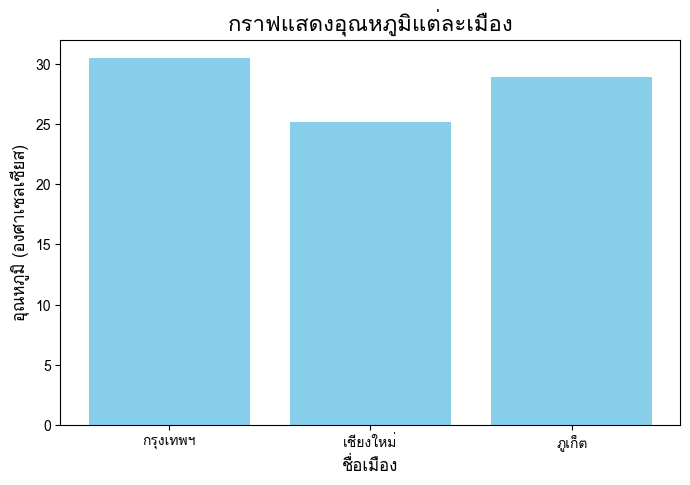

In [110]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [111]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [112]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


**เซลล์ 1.1**: การเข้าถึงข้อมูลใน Series (s['a'] vs s.iloc[0] vs s[['a', 'c']])s["a"]   
**ชนิดผลลัพธ์:** สเกลาร์ (Scalar Value / numpy.int64).

**รูปร่างผลลัพธ์:** ไม่มีมิติ (()).   

**ความหมาย:** ดึงค่าของข้อมูลโดยอ้างอิงจาก ชื่อ Index (Label) ที่ชื่อว่า "a".   

**สถานการณ์ที่ควรใช้:** เมื่อทราบชื่อ Index ที่แน่นอน และต้องการนำค่านั้นไปใช้คำนวณหรือประมวลผลต่อทันที.

In [113]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


### เซลล์ 1.2: การเลือกคอลัมน์ `df["city"]` vs `df[["city"]]`

**ชนิดผลลัพธ์:** `df["city"]` เป็น Series ส่วน `df[["city"]]` เป็น DataFrame

**รูปร่างผลลัพธ์:** `df["city"]` มีรูปร่าง `(2075,)` ส่วน `df[["city"]]` มีรูปร่าง `(2075, 1)`

**ความหมาย:** การใช้วงเล็บเหลี่ยมชั้นเดียวจะเลือกคอลัมน์ออกมาเป็น Series ส่วนการใช้วงเล็บเหลี่ยมสองชั้นจะยังคงโครงสร้างเป็น DataFrame ที่มี 1 คอลัมน์

**สถานการณ์ที่ควรใช้:** ใช้ `df["city"]` เมื่อต้องการนำคอลัมน์ไปคำนวณหรือใช้งานแบบ Series และใช้ `df[["city"]]` เมื่อต้องการรักษารูปแบบ DataFrame เพื่อใช้งานต่อกับคำสั่งที่ต้องการตาราง

In [114]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


### เซลล์ 1.3: `df.loc[0:3]` vs `df.iloc[0:3]`

**ชนิดผลลัพธ์:** ทั้ง `df.loc[0:3]` และ `df.iloc[0:3]` เป็น DataFrame

**รูปร่างผลลัพธ์:** `df.loc[0:3]` มีรูปร่าง `(4, 10)` ส่วน `df.iloc[0:3]` มีรูปร่าง `(3, 10)`

**ความหมาย:** `loc` เลือกข้อมูลโดยอ้างอิงจาก Label และในการ slicing จะรวมตำแหน่งปลายทางด้วย จึงได้แถว 0, 1, 2 และ 3 ส่วน `iloc` เลือกตามตำแหน่งและไม่รวมตำแหน่งปลายทาง จึงได้แถว 0, 1 และ 2

**สถานการณ์ที่ควรใช้:** ใช้ `loc` เมื่อต้องการเลือกข้อมูลโดยอ้างอิงจาก Label และใช้ `iloc` เมื่อต้องการเลือกข้อมูลตามตำแหน่งของแถวหรือคอลัมน์

In [115]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


### เซลล์ 1.4: `count()` vs `size()`

**ชนิดผลลัพธ์:** ทั้งสองคำสั่งให้ผลลัพธ์เป็น Series ที่สรุปข้อมูลตามเมือง

**รูปร่างผลลัพธ์:** ทั้งสองมี 1 ค่าในแต่ละเมือง แต่ค่าที่ได้อาจแตกต่างกันเมื่อมีข้อมูลที่เป็น NaN

**ความหมาย:** `count()` นับเฉพาะค่าที่มีข้อมูลและไม่เป็น NaN ส่วน `size()` นับจำนวนแถวทั้งหมดในแต่ละกลุ่มโดยไม่สนใจว่าค่าจะเป็น NaN หรือไม่

**สถานการณ์ที่ควรใช้:** ใช้ `count()` เมื่อต้องการทราบจำนวนข้อมูลที่มีค่าจริง และใช้ `size()` เมื่อต้องการทราบจำนวนแถวทั้งหมดของแต่ละกลุ่ม

In [116]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


### เซลล์ 1.5: `groupby().mean()` แบบ Series vs DataFrame

**ชนิดผลลัพธ์:** `df.groupby("city")["temperature_c"].mean()` เป็น Series ส่วน `df.groupby("city")[["temperature_c"]].mean()` เป็น DataFrame

**รูปร่างผลลัพธ์:** แบบแรกเป็น Series ที่มีจำนวนสมาชิกเท่ากับจำนวนเมือง ส่วนแบบที่สองเป็น DataFrame ที่มีจำนวนแถวเท่ากับจำนวนเมืองและมี 1 คอลัมน์

**ความหมาย:** ทั้งสองคำสั่งคำนวณค่าเฉลี่ยอุณหภูมิของแต่ละเมืองเหมือนกัน แต่ชนิดของผลลัพธ์ต่างกัน เพราะการเลือก `temperature_c` แบบ `[]` ให้เป็น Series และ `[[]]` ให้เป็น DataFrame

**สถานการณ์ที่ควรใช้:** ใช้รูปแบบ Series เมื่อต้องการนำค่าค่าเฉลี่ยไปคำนวณต่อ และใช้รูปแบบ DataFrame เมื่อต้องการรักษาผลลัพธ์ให้อยู่ในรูปแบบตาราง

In [117]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


### เซลล์ 1.6: `a + b` vs `a.to_numpy() + b.to_numpy()`

**ชนิดผลลัพธ์:** `a + b` ได้ผลลัพธ์เป็น Series ส่วน `a.to_numpy() + b.to_numpy()` ได้ผลลัพธ์เป็น NumPy array

**รูปร่างผลลัพธ์:** ทั้งสองมีข้อมูล 3 ค่า แต่ Series จะมี Index ติดมาด้วย ขณะที่ NumPy array จะมีเฉพาะค่าข้อมูล

**ความหมาย:** การบวก Series ของ Pandas จะจับคู่ข้อมูลตาม Index ดังนั้น `x`, `y`, `z` จะถูกจับคู่กันแม้ว่าลำดับของข้อมูลใน `b` จะต่างกัน ส่วน `to_numpy()` จะนำข้อมูลออกจากโครงสร้าง Series ทำให้ไม่มี Index และคำนวณตามตำแหน่งของข้อมูลแทน

**สถานการณ์ที่ควรใช้:** ใช้การบวกแบบ Series เมื่อต้องการให้ Pandas จับคู่ข้อมูลตาม Index และใช้ NumPy array เมื่อต้องการคำนวณตามตำแหน่งของข้อมูลโดยไม่สนใจ Index

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [118]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [119]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=False)

print("1) 3 เมืองที่มีปริมาณฝนรวมสูงสุด")
print(rain_by_city.head(3))

print("\n2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)")
rain_share_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
print(rain_share_pct)

print("\n3) จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง")
print((rain_by_city > rain_by_city.mean()).sum())


1) 3 เมืองที่มีปริมาณฝนรวมสูงสุด
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)
city
Singapore       10.43
Bangkok          8.21
Lagos            7.82
Mumbai           5.84
Chiang Mai       5.22
Sao Paulo        5.07
Nairobi          4.74
Tokyo            4.61
Auckland         4.22
Paris            3.99
Sydney           3.97
Toronto          3.81
New York         3.78
Mexico City      3.66
Buenos Aires     3.65
London           3.27
Berlin           3.21
Beijing          3.00
Moscow           2.96
Cape Town        2.87
Lima             2.16
Los Angeles      2.03
Cairo            1.47
Name: rainfall_mm, dtype: float64

3) จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
8


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [120]:
# คำตอบข้อ 2.2
city_profile = (
    df.groupby("city")
      .agg(
          country=("country", "first"),
          region=("region", "first"),
          n_records=("date", "size"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum"),
      )
      .reset_index()
      [["city", "country", "region", "n_records", "avg_temp", "total_rain"]]
)

print(city_profile.round(2))

            city       country         region  n_records  avg_temp  total_rain
0       Auckland   New Zealand        Oceania         90     17.80       351.9
1        Bangkok      Thailand           Asia         91     32.45       685.6
2        Beijing         China           Asia         90     15.60       250.1
3         Berlin       Germany         Europe         90     12.38       268.4
4   Buenos Aires     Argentina  South America         90     19.17       305.1
5          Cairo         Egypt         Africa         91     26.09       123.0
6      Cape Town  South Africa         Africa         90     30.16       239.3
7     Chiang Mai      Thailand           Asia         91     29.68       435.6
8          Lagos       Nigeria         Africa         90     29.49       652.8
9           Lima          Peru  South America         90     21.49       180.3
10        London            UK         Europe         90     13.49       273.3
11   Los Angeles           USA  North America       

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [121]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [122]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [123]:
# คำตอบข้อ 3.1
typed_path = BASE + "world_weather_sample.csv"

df_typed = pd.read_csv(
    typed_path,
    usecols=[
        "date", "city", "region",
        "temperature_c", "humidity_pct", "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city",
)

print(df_typed.dtypes)
df_typed.info()


date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [124]:
# คำตอบข้อ 3.2
raw_df = pd.read_csv(BASE + "world_weather_sample.csv")
typed_df = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date", "city", "region",
        "temperature_c", "humidity_pct", "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city",
)

raw_mem = raw_df.memory_usage(deep=True)
typed_mem = typed_df.memory_usage(deep=True)

memory_compare = pd.DataFrame({
    "normal_bytes": raw_mem.reindex(typed_mem.index, fill_value=0),
    "typed_bytes": typed_mem,
})
memory_compare["reduction_pct"] = (
    (memory_compare["normal_bytes"] - memory_compare["typed_bytes"])
    / memory_compare["normal_bytes"].replace(0, np.nan) * 100
).round(2)

print("หน่วยความจำรวมแบบปกติ:", raw_mem.sum(), "bytes")
print("หน่วยความจำรวมจากข้อ 3.1:", typed_mem.sum(), "bytes")
print(
    "ลดลงคิดเป็นร้อยละ:",
    round((1 - typed_mem.sum() / raw_mem.sum()) * 100, 2)
)
print("\nเปรียบเทียบรายคอลัมน์")
print(memory_compare)

largest_effect = memory_compare["normal_bytes"].sub(memory_compare["typed_bytes"]).idxmax()
print(
    f"\nคอลัมน์ที่ช่วยลดหน่วยความจำมากที่สุดคือ {largest_effect} "
    "เพราะชนิดข้อมูลที่ใช้มีขนาด/รูปแบบการเก็บที่ประหยัดกว่าการอ่านแบบปกติ"
)
print(
    "สำหรับ city และ region การกำหนดเป็น category มีผลมากเป็นพิเศษ "
    "เมื่อมีค่าซ้ำจำนวนมาก เพราะ pandas เก็บหมวดหมู่และรหัสแทนการเก็บสตริงซ้ำทุกแถว"
)


หน่วยความจำรวมแบบปกติ: 571645 bytes
หน่วยความจำรวมจากข้อ 3.1: 72917 bytes
ลดลงคิดเป็นร้อยละ: 87.24

เปรียบเทียบรายคอลัมน์
               normal_bytes  typed_bytes  reduction_pct
Index                   132         3927       -2875.00
date                 122425        16600          86.44
region               117631         2590          97.80
temperature_c         16600        16600           0.00
humidity_pct          16600        16600           0.00
rainfall_mm           16600        16600           0.00

คอลัมน์ที่ช่วยลดหน่วยความจำมากที่สุดคือ region เพราะชนิดข้อมูลที่ใช้มีขนาด/รูปแบบการเก็บที่ประหยัดกว่าการอ่านแบบปกติ
สำหรับ city และ region การกำหนดเป็น category มีผลมากเป็นพิเศษ เมื่อมีค่าซ้ำจำนวนมาก เพราะ pandas เก็บหมวดหมู่และรหัสแทนการเก็บสตริงซ้ำทุกแถว


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [125]:
# คำตอบข้อ 3.3
sum_by_city = pd.Series(dtype="float64")
count_by_city = pd.Series(dtype="float64")
global_min = np.inf
global_max = -np.inf

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=500
):
    t = chunk["temperature_c"].dropna()

    if not t.empty:
        global_min = min(global_min, t.min())
        global_max = max(global_max, t.max())

    piece = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])
    sum_by_city = sum_by_city.add(piece["sum"], fill_value=0)
    count_by_city = count_by_city.add(piece["count"], fill_value=0)

avg_temp_by_city = sum_by_city.div(count_by_city)

print("อุณหภูมิต่ำสุดทั้งไฟล์:", global_min)
print("อุณหภูมิสูงสุดทั้งไฟล์:", global_max)
print("\nอุณหภูมิเฉลี่ยรายเมือง")
print(avg_temp_by_city.sort_index().round(2))

print(
    "\nอธิบาย: ไม่ควรนำค่าเฉลี่ยของแต่ละ chunk มาเฉลี่ยกันตรง ๆ "
    "เพราะแต่ละ chunk อาจมีจำนวนข้อมูลที่ใช้คำนวณเฉลี่ยไม่เท่ากัน "
    "จึงต้องสะสมผลรวม (sum) และจำนวนข้อมูลที่ไม่ว่าง (count) "
    "แล้วค่อยคำนวณ sum / count ตอนสุดท้าย"
)


อุณหภูมิต่ำสุดทั้งไฟล์: -88.0
อุณหภูมิสูงสุดทั้งไฟล์: 999.0

อุณหภูมิเฉลี่ยรายเมือง
city
Auckland        17.80
Bangkok         32.45
Beijing         15.60
Berlin          12.38
Buenos Aires    19.17
Cairo           26.09
Cape Town       30.16
Chiang Mai      29.68
Lagos           29.49
Lima            21.49
London          13.49
Los Angeles     20.66
Mexico City     19.19
Moscow           7.23
Mumbai          30.87
Nairobi         21.44
New York        15.48
Paris           25.81
Sao Paulo       22.84
Singapore       40.08
Sydney          20.35
Tokyo           18.41
Toronto         11.61
dtype: float64

อธิบาย: ไม่ควรนำค่าเฉลี่ยของแต่ละ chunk มาเฉลี่ยกันตรง ๆ เพราะแต่ละ chunk อาจมีจำนวนข้อมูลที่ใช้คำนวณเฉลี่ยไม่เท่ากัน จึงต้องสะสมผลรวม (sum) และจำนวนข้อมูลที่ไม่ว่าง (count) แล้วค่อยคำนวณ sum / count ตอนสุดท้าย


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [127]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [128]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [129]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "example_value": df.where(df.notna()).bfill().iloc[0].reindex(df.columns),
}).sort_values("n_missing", ascending=False)

print(summary)


                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [130]:
# คำตอบข้อ 4.2
temp_bad = ~df["temperature_c"].between(-60, 60) & df["temperature_c"].notna()
humidity_bad = ~df["humidity_pct"].between(0, 100) & df["humidity_pct"].notna()
any_bad = temp_bad | humidity_bad

print("1) temperature_c อยู่นอกช่วง -60 ถึง 60:", temp_bad.sum())
print("2) humidity_pct อยู่นอกช่วง 0 ถึง 100:", humidity_bad.sum())
print("3) มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์:", any_bad.sum())

print("\nตัวอย่างแถวที่ผิดปกติ")
print(df.loc[any_bad, ["city", "date", "temperature_c", "humidity_pct"]].head(10))


1) temperature_c อยู่นอกช่วง -60 ถึง 60: 5
2) humidity_pct อยู่นอกช่วง 0 ถึง 100: 3
3) มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: 8

ตัวอย่างแถวที่ผิดปกติ
              city        date  temperature_c  humidity_pct
25       Singapore  2025-03-05           31.5         150.0
37     Los Angeles  2025-01-27           17.3         150.0
78       Cape Town  2025-02-10          999.0          61.2
499      Singapore  2025-01-16          -88.0          96.4
712          Paris  2025-03-28          999.0          82.7
1280  Buenos Aires  2025-01-19          -88.0          63.5
1855     Singapore  2025-03-11          999.0          72.0
2068       Bangkok  2025-02-25           34.4         150.0


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [131]:
# คำตอบข้อ 4.3
country_norm = df["country"].astype("string").str.strip().str.casefold()

variants = (
    pd.DataFrame({"original": df["country"], "normalized": country_norm})
      .dropna()
      .drop_duplicates()
      .groupby("normalized")["original"]
      .agg(lambda s: sorted(s.tolist()))
)

print("1) กลุ่มค่าที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกกัน")
print(variants[variants.str.len() > 1])

title_versions = (
    df["country"].astype("string")
      .dropna()
      .drop_duplicates()
      .to_frame("original")
)
title_versions["title_version"] = title_versions["original"].str.title()
title_changed = title_versions[title_versions["original"] != title_versions["title_version"]]

print("\n2) ค่าที่เปลี่ยนเมื่อใช้ str.title()")
print(title_changed)

print(
    "\nstr.title() ไม่ใช่วิธี normalize ที่ปลอดภัย เพราะจะบังคับตัวอักษร "
    "ของทุกคำให้เป็นรูป Title Case และอาจเปลี่ยนรูปแบบการเขียนที่เป็นทางการของชื่อประเทศ "
    "โดยเฉพาะชื่อที่มีคำหรืออักษรย่อที่ต้องคงรูปเดิม"
)

# 3) normalize ที่ใช้จริง: ตัดช่องว่างหัวท้าย + casefold
df_clean_country = df.copy()
df_clean_country["country"] = (
    df_clean_country["country"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

print("\nจำนวนประเทศหลัง normalize:", df_clean_country["country"].nunique())
print("การ normalize แบบนี้แยกปัญหาเรื่องช่องว่างและตัวพิมพ์ออกจากกันได้อย่างปลอดภัยกว่า")


1) กลุ่มค่าที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกกัน
normalized
argentina          [ARGENTINA, Argentina]
canada                   [CANADA, Canada]
germany                [GERMANY, Germany]
japan                      [JAPAN, Japan]
kenya                      [KENYA, Kenya]
new zealand    [NEW ZEALAND, New Zealand]
singapore          [SINGAPORE, Singapore]
Name: original, dtype: object

2) ค่าที่เปลี่ยนเมื่อใช้ str.title()
         original title_version
0             USA           Usa
44             UK            Uk
366       GERMANY       Germany
433        CANADA        Canada
1127    SINGAPORE     Singapore
1330  NEW ZEALAND   New Zealand
1371    ARGENTINA     Argentina
1493        JAPAN         Japan
1770        KENYA         Kenya

str.title() ไม่ใช่วิธี normalize ที่ปลอดภัย เพราะจะบังคับตัวอักษร ของทุกคำให้เป็นรูป Title Case และอาจเปลี่ยนรูปแบบการเขียนที่เป็นทางการของชื่อประเทศ โดยเฉพาะชื่อที่มีคำหรืออักษรย่อที่ต้องคงรูปเดิม

จำนวนประเทศหลัง normalize: 21
การ normalize แบบนี้แยกปัญ

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [132]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [133]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [134]:
# คำตอบข้อ 5.1
print("1) ตำแหน่งเลขคู่ 10 แถวแรก และ 3 คอลัมน์สุดท้าย")
print(df.iloc[0:20:2, -3:])

print("\n2) 5 แถวสุดท้ายจากล่างขึ้นบน")
print(df.iloc[::-1].head(5))

middle_pos = len(df) // 2
print(
    "\n3) ค่าที่อยู่แถวกึ่งกลางและคอลัมน์สุดท้าย:",
    df.iloc[middle_pos, -1]
)

1) ตำแหน่งเลขคู่ 10 แถวแรก และ 3 คอลัมน์สุดท้าย
    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6

2) 5 แถวสุดท้ายจากล่างขึ้นบน
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      tempera

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [135]:
# คำตอบข้อ 5.2
multi = df.set_index(["region", "city"]).sort_index()

print("1) Asia เฉพาะ date และ temperature_c")
print(multi.loc["Asia", ["date", "temperature_c"]])

print("\n2) Tokyo และ Bangkok")
print(
    multi.loc[
        [("Asia", "Tokyo"), ("Asia", "Bangkok")],
        :
    ]
)

city_mask = multi.index.get_level_values("city").str.startswith("B", na=False)
print("\n3) ทุกภูมิภาค แต่ชื่อเมืองขึ้นต้นด้วย B")
print(multi.loc[city_mask])

print(
    "\nอธิบาย: ควร sort_index() เพราะ MultiIndex ที่เรียงแล้วทำให้ "
    "การ slice/เลือกช่วงของ index หลายระดับทำงานถูกต้องและมีประสิทธิภาพมากกว่า "
    "รวมทั้งหลีกเลี่ยงปัญหา UnsortedIndexError ในบางรูปแบบของการเลือกข้อมูล"
)


1) Asia เฉพาะ date และ temperature_c
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0
...             ...            ...
Tokyo    2025-01-08           15.3
Tokyo    2025-02-19           19.1
Tokyo    2025-01-02           16.3
Tokyo    2025-03-30           20.4
Tokyo    2025-03-06           16.6

[542 rows x 2 columns]

2) Tokyo และ Bangkok
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Tokyo          220  2025-02-09     Japan           18.3          60.6   
       Tokyo          260  2025-03-21     Japan           19.7          67.4   
       Tokyo          262  2025-03-23     Japan           17.7          60.2   
       Tokyo          203  2025-01-23     Japan           20.8

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [136]:
# คำตอบข้อ 5.3
# ทดลองกับสำเนาเพื่อไม่ทำลายข้อมูลต้นฉบับสำหรับข้อถัดไป
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0

# รูปแบบที่ 1: ถ้าต้องการแก้ df จริง ให้ใช้ .loc[]
df_edit = df.copy()
df_edit.loc[df_edit["city"] == "Bangkok", "temperature_c"] = 0
print("รูปแบบแก้ DataFrame โดยตรง")
print(df_edit.loc[df_edit["city"] == "Bangkok", ["city", "temperature_c"]].head())

# รูปแบบที่ 2: ถ้าต้องการสำเนาแยกต่างหาก ให้ใช้ .copy()
subset_copy = df.loc[df["city"] == "Bangkok"].copy()
subset_copy.loc[:, "temperature_c"] = 0
print("\nรูปแบบทำงานกับสำเนาแยกต่างหาก")
print(subset_copy[["city", "temperature_c"]].head())

print(
    "\nแนวปฏิบัติ: ถ้าตั้งใจแก้ต้นฉบับ ให้ใช้ df.loc[เงื่อนไข, คอลัมน์] = ค่า "
    "แต่ถ้าจะนำ subset ไปแก้ต่อโดยไม่กระทบต้นฉบับ ให้ต่อ .copy() เสมอ"
)


รูปแบบแก้ DataFrame โดยตรง
        city  temperature_c
67   Bangkok            0.0
79   Bangkok            0.0
82   Bangkok            0.0
84   Bangkok            0.0
108  Bangkok            0.0

รูปแบบทำงานกับสำเนาแยกต่างหาก
        city  temperature_c
67   Bangkok            0.0
79   Bangkok            0.0
82   Bangkok            0.0
84   Bangkok            0.0
108  Bangkok            0.0

แนวปฏิบัติ: ถ้าตั้งใจแก้ต้นฉบับ ให้ใช้ df.loc[เงื่อนไข, คอลัมน์] = ค่า แต่ถ้าจะนำ subset ไปแก้ต่อโดยไม่กระทบต้นฉบับ ให้ต่อ .copy() เสมอ


/tmp/ipykernel_1279/4128566761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [137]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [138]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [139]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [140]:
# คำตอบข้อ 6.1
q1 = df[
    (df["region"] == "Asia") &
    (df["rainfall_mm"] > 5) &
    (df["wind_speed_kmh"] > 20)
]

q2 = df[
    ~df["city"].isin(["Bangkok", "Tokyo", "London"]) &
    df["humidity_pct"].between(40, 60, inclusive="both")
]

q3 = df[df.isna().sum(axis=1) >= 2]

q4 = df[
    df["city"].astype("string").str.contains(
        r"New|San", regex=True, case=False, na=False
    )
]

print("1)", q1.shape)
print("2)", q2.shape)
print("3)", q3.shape)
print("4)", q4[["city", "date"]].head(10))


1) (54, 10)
2) (470, 10)
3) (8, 10)
4)          city        date
0    New York  2025-03-24
47   New York  2025-03-20
63   New York  2025-01-17
98   New York  2025-03-01
123  New York  2025-01-08
135  New York  2025-01-13
159  New York  2025-02-15
171  New York  2025-02-24
173  New York  2025-03-04
213  New York  2025-02-28


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [141]:
# คำตอบข้อ 6.2
df["temperature_valid"] = df["temperature_c"].where(
    df["temperature_c"].between(-60, 60)
)

rain_p99 = df["rainfall_mm"].quantile(0.99)
df["rainfall_capped_p99"] = df["rainfall_mm"].mask(
    df["rainfall_mm"] > rain_p99,
    rain_p99
)

print(df[[
    "temperature_c", "temperature_valid",
    "rainfall_mm", "rainfall_capped_p99"
]].head())

print("\nเปอร์เซ็นไทล์ที่ 99 ของฝน:", rain_p99)
print(
    "\nอธิบาย: where/mask รักษาจำนวนแถวไว้ แล้วเปลี่ยนเฉพาะค่าที่ผิดปกติ "
    "หรือเกินเกณฑ์ ทำให้ยังนำข้อมูลของช่วงเวลา/เมืองเดิมไปวิเคราะห์ต่อได้ "
    "ในขณะที่การลบแถวทิ้งจะทำให้ขนาดตัวอย่างลดลงและอาจทำให้การเปรียบเทียบระหว่างกลุ่มเอนเอียง"
)


   temperature_c  temperature_valid  rainfall_mm  rainfall_capped_p99
0           15.7               15.7          6.3                  6.3
1           18.3               18.3          0.0                  0.0
2           20.6               20.6          1.2                  1.2
3           31.0               31.0          8.0                  8.0
4           19.1               19.1          0.0                  0.0

เปอร์เซ็นไทล์ที่ 99 ของฝน: 14.687999999999988

อธิบาย: where/mask รักษาจำนวนแถวไว้ แล้วเปลี่ยนเฉพาะค่าที่ผิดปกติ หรือเกินเกณฑ์ ทำให้ยังนำข้อมูลของช่วงเวลา/เมืองเดิมไปวิเคราะห์ต่อได้ ในขณะที่การลบแถวทิ้งจะทำให้ขนาดตัวอย่างลดลงและอาจทำให้การเปรียบเทียบระหว่างกลุ่มเอนเอียง


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [142]:
# คำตอบข้อ 6.3
tmp = df.assign(
    city_avg=df.groupby("city")["temperature_c"].transform("mean")
)
tmp = tmp.assign(
    deviation=(tmp["temperature_c"] - tmp["city_avg"]).abs()
).dropna(subset=["temperature_c", "deviation"])

idx = tmp.groupby("city")["deviation"].idxmax()

result_63 = (
    tmp.loc[idx, ["city", "date", "temperature_c", "deviation"]]
       .sort_values("city")
       .reset_index(drop=True)
)

print(result_63.round(2))


            city        date  temperature_c  deviation
0       Auckland  2025-02-27           25.6       7.80
1        Bangkok  2025-03-26           39.1       6.65
2        Beijing  2025-03-06           22.6       7.00
3         Berlin  2025-03-26           19.4       7.02
4   Buenos Aires  2025-01-19          -88.0     107.17
5          Cairo  2025-03-31           33.6       7.51
6      Cape Town  2025-02-10          999.0     968.84
7     Chiang Mai  2025-03-28           37.3       7.62
8          Lagos  2025-01-01           21.1       8.39
9           Lima  2025-01-22           12.9       8.59
10        London  2025-02-09           23.4       9.91
11   Los Angeles  2025-01-09           13.4       7.26
12   Mexico City  2025-02-24           26.5       7.31
13        Moscow  2025-01-20           -0.2       7.43
14        Mumbai  2025-01-07           24.2       6.67
15       Nairobi  2025-03-11           27.8       6.36
16      New York  2025-03-16           24.5       9.02
17        

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [143]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [144]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [145]:
# คำตอบข้อ 7.1
df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5,
)

print(df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head())


        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True
3 2025-01-19    2025-01             3    Sunday        True
4 2025-02-03    2025-02             6    Monday       False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [146]:
# คำตอบข้อ 7.2
full_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
observed_dates = pd.DatetimeIndex(df["date"].dt.normalize().dropna().unique()).sort_values()
missing_dates = full_dates.difference(observed_dates)

print("1) จำนวนวันตามช่วงวันที่:", len(full_dates))
print("วันที่ไม่มีข้อมูลเลย:", missing_dates.tolist())

weekend_temp = (
    df.groupby(["region", "is_weekend"])["temperature_c"]
      .mean()
      .unstack()
      .rename(columns={False: "วันธรรมดา", True: "วันหยุดสุดสัปดาห์"})
      .round(2)
)
print("\n2) อุณหภูมิเฉลี่ยวันหยุดสุดสัปดาห์เทียบวันธรรมดา จำแนกตามภูมิภาค")
print(weekend_temp)

# แก้ไขโดยใช้ df["date"].dt.month แทนการเรียกคอลัมน์ "month"
monthly_rain = (
    df.groupby(["city", df["date"].dt.month])["rainfall_mm"]
      .sum()
      .rename("total_rain")
      .reset_index()
)
max_month_idx = monthly_rain.groupby("city")["total_rain"].idxmax()

print("\n3) เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง")
print(
    monthly_rain.loc[max_month_idx]
    .sort_values("city")
    .reset_index(drop=True)
    .round(2)
)


1) จำนวนวันตามช่วงวันที่: 90
วันที่ไม่มีข้อมูลเลย: []

2) อุณหภูมิเฉลี่ยวันหยุดสุดสัปดาห์เทียบวันธรรมดา จำแนกตามภูมิภาค
is_weekend     วันธรรมดา  วันหยุดสุดสัปดาห์
region                                     
Africa             27.94              23.88
Asia               28.49              26.53
Europe             15.82              11.95
North America      16.72              16.84
Oceania            18.94              19.40
South America      21.70              19.84

3) เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
            city  date  total_rain
0       Auckland     3       150.0
1        Bangkok     2       243.9
2        Beijing     2        87.4
3         Berlin     3       100.1
4   Buenos Aires     2       121.2
5          Cairo     2        48.0
6      Cape Town     1        98.3
7     Chiang Mai     3       188.0
8          Lagos     3       233.0
9           Lima     1        88.0
10        London     1       117.2
11   Los Angeles     1        78.6
12   Mexico City     1      

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [147]:
# คำตอบข้อ 7.3
bkk_7d = (
    df.loc[df["city"] == "Bangkok", ["date", "temperature_c", "rainfall_mm"]]
      .set_index("date")
      .sort_index()
      .resample("7D")
      .agg(
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum"),
      )
)

print(bkk_7d.round(2))

print(
    "\nอธิบาย: resample() ใช้เมื่อข้อมูลมี DatetimeIndex และต้องการสรุปตาม "
    "ช่วงเวลาที่ต่อเนื่องจริง เช่น 7 วัน, 1 เดือน หรือ 1 ชั่วโมง "
    "ส่วน groupby(df['date'].dt.month) จะแบ่งตามหมายเลขเดือนอย่างเดียว "
    "และไม่ได้สร้างช่วงเวลาตามปฏิทิน/ระยะเวลาต่อเนื่องแบบ resample"
)


            avg_temp  total_rain
date                            
2025-01-01     30.36        65.7
2025-01-08     31.09        47.6
2025-01-15     30.39        58.7
2025-01-22     32.29        50.0
2025-01-29     31.76        55.4
2025-02-05     33.03        65.1
2025-02-12     34.21        60.2
2025-02-19     32.30        42.5
2025-02-26     32.34        61.7
2025-03-05     32.99        49.1
2025-03-12     33.04        56.4
2025-03-19     33.16        41.9
2025-03-26     35.40        31.3

อธิบาย: resample() ใช้เมื่อข้อมูลมี DatetimeIndex และต้องการสรุปตาม ช่วงเวลาที่ต่อเนื่องจริง เช่น 7 วัน, 1 เดือน หรือ 1 ชั่วโมง ส่วน groupby(df['date'].dt.month) จะแบ่งตามหมายเลขเดือนอย่างเดียว และไม่ได้สร้างช่วงเวลาตามปฏิทิน/ระยะเวลาต่อเนื่องแบบ resample


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [148]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [149]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [150]:
# คำตอบข้อ 8.1
base_cols = [
    c for c in [
        "date", "city", "country", "region",
        "temperature_c", "humidity_pct",
        "rainfall_mm", "wind_speed_kmh", "pressure_hpa"
    ] if c in df.columns
]
missing_by_col = pd.DataFrame({
    "n_missing": df[base_cols].isna().sum(),
    "pct_missing": (df[base_cols].isna().mean() * 100).round(2)
}).sort_values("n_missing", ascending=False)

print("1) คอลัมน์ที่มีค่าว่างมากที่สุด")
print(missing_by_col.head(1))

city_missing_temp = (
    df.groupby("city")["temperature_c"]
      .apply(lambda s: s.isna().mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)
print("\n2) สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง (%)")
print(city_missing_temp)

dropna_df = df.dropna()
remaining_pct = len(dropna_df) / len(df) * 100
loss_by_city = (
    1 - dropna_df["city"].value_counts()
    .div(df["city"].value_counts())
).sort_values(ascending=False) * 100

print("\n3) หลัง dropna() เหลือข้อมูลคิดเป็นร้อยละ:", round(remaining_pct, 2))
print("เมืองที่สูญเสียข้อมูลมากที่สุด:", loss_by_city.idxmax(),
      "คิดเป็นร้อยละ", round(loss_by_city.max(), 2))


1) คอลัมน์ที่มีค่าว่างมากที่สุด
              n_missing  pct_missing
humidity_pct         82         3.95

2) สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง (%)
city
Lagos           3.33
London          2.22
Toronto         2.22
Tokyo           2.22
Cairo           2.20
Berlin          1.11
Beijing         1.11
Paris           1.11
Sao Paulo       1.11
Cape Town       1.11
Buenos Aires    1.11
Los Angeles     1.11
Moscow          1.10
Nairobi         1.10
Bangkok         0.00
Auckland        0.00
Mexico City     0.00
Chiang Mai      0.00
Lima            0.00
Mumbai          0.00
New York        0.00
Sydney          0.00
Singapore       0.00
Name: temperature_c, dtype: float64

3) หลัง dropna() เหลือข้อมูลคิดเป็นร้อยละ: 88.72
เมืองที่สูญเสียข้อมูลมากที่สุด: Auckland คิดเป็นร้อยละ 15.56


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [151]:
# คำตอบข้อ 8.2
global_mean = df["temperature_c"].mean()

fill_global = df["temperature_c"].fillna(global_mean)

city_mean = df.groupby("city")["temperature_c"].transform("mean")
fill_city = df["temperature_c"].fillna(city_mean)

sorted_order = df.sort_values(["city", "date"]).index
sorted_temp = df.loc[sorted_order, ["city", "date", "temperature_c"]].copy()
sorted_temp["fill_previous"] = sorted_temp.groupby("city")["temperature_c"].ffill()
fill_previous = sorted_temp["fill_previous"].reindex(df.index)

def city_stats(series, label):
    return (
        pd.DataFrame({"temperature_c": series, "city": df["city"]})
        .groupby("city")["temperature_c"]
        .agg(avg_temp="mean", std_temp="std")
        .rename(columns={
            "avg_temp": f"{label}_avg",
            "std_temp": f"{label}_std"
        })
    )

comparison = (
    city_stats(fill_global, "global")
    .join(city_stats(fill_city, "city"))
    .join(city_stats(fill_previous, "previous"))
)

print(comparison.round(2))
print(
    "\nอธิบาย: โดยทั่วไปการเติมด้วยค่าเฉลี่ยของเมืองเหมาะกับชุดข้อมูลนี้มากกว่า "
    "เพราะรักษาระดับพื้นฐานของแต่ละเมืองไว้และไม่ดึงค่าเฉลี่ยรวมทุกเมืองมาปนกัน "
    "ส่วนการเติมด้วยค่าก่อนหน้าสามารถทำให้ความแปรปรวนลดลง โดยเฉพาะเมื่อมีค่าว่างต่อเนื่องหลายวัน "
    "จึงต้องระวังการทำให้ข้อมูลดูเรียบเกินจริง"
)


              global_avg  global_std  city_avg  city_std  previous_avg  \
city                                                                     
Auckland           17.80        2.80     17.80      2.80         17.80   
Bangkok            32.45        2.48     32.45      2.48         32.45   
Beijing            15.67        2.93     15.60      2.86         15.62   
Berlin             12.49        2.77     12.38      2.58         12.34   
Buenos Aires       19.20       11.75     19.17     11.75         19.14   
Cairo              26.00        2.77     26.09      2.70         25.98   
Cape Town          30.07      103.32     30.16    103.31         30.02   
Chiang Mai         29.68        2.86     29.68      2.86         29.68   
Lagos              29.24        3.11     29.49      2.79         29.52   
Lima               21.49        3.11     21.49      3.11         21.49   
London             13.68        3.23     13.49      2.98         13.50   
Los Angeles        20.67        3.00  

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [152]:
# คำตอบข้อ 8.3
key_dup_mask = df.duplicated(subset=["city", "date"], keep=False)
full_dup_count = df.duplicated(keep=False).sum()
key_dup_pair_count = df.loc[key_dup_mask, ["city", "date"]].drop_duplicates().shape[0]

value_cols = [
    c for c in [
        "temperature_c", "humidity_pct",
        "rainfall_mm", "wind_speed_kmh", "pressure_hpa"
    ] if c in df.columns
]

conflict_keys = (
    df.loc[key_dup_mask]
      .groupby(["city", "date"])[value_cols]
      .nunique(dropna=False)
      .gt(1)
      .any(axis=1)
)

print("1) จำนวนคู่ (city, date) ที่ซ้ำ:", key_dup_pair_count)
print("จำนวนแถวที่ซ้ำทุกคอลัมน์:", full_dup_count)

print("\n2) จำนวน key ที่ซ้ำแต่ค่าที่วัดได้ต่างกัน:", conflict_keys.sum())
print("ตัวอย่าง key ที่ค่าต่างกัน")
print(conflict_keys[conflict_keys].head(10))

# นโยบาย: ในโจทย์นี้ถือว่าหนึ่ง (city, date) ต้องมีเพียงหนึ่งระเบียน
dedup_df = (
    df.sort_values(["city", "date"])
      .drop_duplicates(subset=["city", "date"], keep="first")
      .copy()
)

expected_rows = df["city"].nunique() * df["date"].nunique()
print("\n3) จำนวนแถวหลังขจัดข้อมูลซ้ำ:", len(dedup_df))
print("จำนวนเมือง x จำนวนวัน:", expected_rows)
print("ตรงตามเงื่อนไขหรือไม่:", len(dedup_df) == expected_rows)
print(
    "\nสรุปนโยบาย: ใช้ drop_duplicates(subset=['city', 'date'], keep='first') "
    "เพราะกำหนดให้ (city, date) เป็นคีย์หนึ่งระเบียนต่อวันและต่อเมือง"
)


1) จำนวนคู่ (city, date) ที่ซ้ำ: 5
จำนวนแถวที่ซ้ำทุกคอลัมน์: 10

2) จำนวน key ที่ซ้ำแต่ค่าที่วัดได้ต่างกัน: 0
ตัวอย่าง key ที่ค่าต่างกัน
Series([], dtype: bool)

3) จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070
จำนวนเมือง x จำนวนวัน: 2070
ตรงตามเงื่อนไขหรือไม่: True

สรุปนโยบาย: ใช้ drop_duplicates(subset=['city', 'date'], keep='first') เพราะกำหนดให้ (city, date) เป็นคีย์หนึ่งระเบียนต่อวันและต่อเมือง


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [153]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 17)


### ตัวอย่าง

In [154]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [155]:
# คำตอบข้อ 9.1
summary_91 = (
    df.groupby("city")
      .agg(
          avg_temp=("temperature_c", "mean"),
          median_temp=("temperature_c", "median"),
          std_temp=("temperature_c", "std"),
          total_rain=("rainfall_mm", "sum"),
          heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
          pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100),
      )
      .sort_index()
)

print(summary_91.round(2))


              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  \
city                                                                         
Auckland         17.80        17.55      2.80       351.9                6   
Bangkok          32.44        32.50      2.49       680.0               23   
Beijing          15.60        15.50      2.87       250.1                2   
Berlin           12.38        12.30      2.60       268.4                6   
Buenos Aires     19.17        20.70     11.82       305.1                9   
Cairo            26.07        25.80      2.74       122.4                1   
Cape Town        30.16        18.90    103.90       239.3                0   
Chiang Mai       29.65        29.50      2.86       428.1                9   
Lagos            29.49        29.80      2.84       652.8               22   
Lima             21.49        21.30      3.11       180.3                1   
London           13.49        13.50      3.02       273.3       

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [156]:
# คำตอบข้อ 9.2
summary_92 = (
    df.groupby(["region", "month"])
      .agg(
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum"),
      )
      .reset_index()
)

max_92 = summary_92.loc[summary_92["avg_temp"].idxmax()]
min_92 = summary_92.loc[summary_92["avg_temp"].idxmin()]

print(summary_92.round(2))
print("\nอุณหภูมิเฉลี่ยสูงสุด:", max_92.to_dict())
print("อุณหภูมิเฉลี่ยต่ำสุด:", min_92.to_dict())


           region  month  avg_temp  total_rain
0          Africa      1     22.64       506.8
1          Africa      2     32.74       450.6
2          Africa      3     25.41       448.1
3            Asia      1     24.20      1034.0
4            Asia      2     26.76      1043.2
5            Asia      3     32.68      1024.4
6          Europe      1     10.40       399.6
7          Europe      2     12.20       349.9
8          Europe      3     21.51       372.5
9   North America      1     15.17       422.2
10  North America      2     17.07       355.6
11  North America      3     18.04       331.1
12        Oceania      1     17.36       240.4
13        Oceania      2     19.73       202.2
14        Oceania      3     20.20       240.7
15  South America      1     19.19       303.5
16  South America      2     22.10       297.9
17  South America      3     22.29       307.2

อุณหภูมิเฉลี่ยสูงสุด: {'region': 'Africa', 'month': 2, 'avg_temp': 32.741441441441445, 'total_rain': 450.6

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [157]:
# คำตอบข้อ 9.3
count_vs_size = (
    df.groupby("city")
      .agg(
          n_days_count=("temperature_c", "count"),
          n_days_size=("temperature_c", "size"),
      )
      .assign(difference=lambda x: x["n_days_size"] - x["n_days_count"])
)

print(count_vs_size)
print(
    "\ncount() นับเฉพาะค่าที่ไม่ว่างใน temperature_c แต่ size() นับจำนวนแถวทั้งหมด "
    "ดังนั้นผลต่างกันเมื่อมีค่าว่างใน temperature_c"
)
print(
    "ถ้ารายงานจำนวนวันโดยใช้ count() ทั้งที่ต้องการจำนวนวันจริง "
    "จะทำให้จำนวนวันของเมืองที่มีอุณหภูมิหายไปถูกนับต่ำกว่าความเป็นจริง"
)


              n_days_count  n_days_size  difference
city                                               
Auckland                90           90           0
Bangkok                 90           90           0
Beijing                 89           90           1
Berlin                  89           90           1
Buenos Aires            89           90           1
Cairo                   88           90           2
Cape Town               89           90           1
Chiang Mai              90           90           0
Lagos                   87           90           3
Lima                    90           90           0
London                  88           90           2
Los Angeles             89           90           1
Mexico City             90           90           0
Moscow                  89           90           1
Mumbai                  90           90           0
Nairobi                 89           90           1
New York                90           90           0
Paris       

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [158]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [159]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [160]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [161]:
# คำตอบข้อ 10.1
city_rain_total = df.groupby("city")["rainfall_mm"].transform("sum")
df["rain_share"] = np.where(
    city_rain_total.eq(0),
    np.nan,
    df["rainfall_mm"] / city_rain_total
)

city_mean = df.groupby("city")["temperature_c"].transform("mean")
city_std = df.groupby("city")["temperature_c"].transform("std")
df["temp_z"] = (df["temperature_c"] - city_mean) / city_std

monthly_city_avg = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = (
    monthly_city_avg
    .groupby(df["city"])
    .rank(method="dense", ascending=False)
)

check_rain_share = df.groupby("city")["rain_share"].sum(min_count=1)

print(df[[
    "city", "date", "rainfall_mm",
    "rain_share", "temperature_c", "temp_z", "city_rank_month"
]].head(10).round(3))

print("\nผลรวม rain_share ต่อเมือง (ควรใกล้ 1)")
print(check_rain_share.round(6))
print(
    "ตรวจทุกเมืองเท่ากับ 1 หรือไม่:",
    np.allclose(
        check_rain_share.dropna().to_numpy(),
        np.ones(check_rain_share.dropna().shape[0]),
        atol=1e-10
    )
)


           city       date  rainfall_mm  rain_share  temperature_c  temp_z  \
0      New York 2025-03-24          6.3       0.020           15.7   0.074   
1         Tokyo 2025-02-09          0.0       0.000           18.3  -0.046   
2   Los Angeles 2025-02-01          1.2       0.007           20.6  -0.019   
3        Mumbai 2025-01-19          8.0       0.016           31.0   0.050   
4     Cape Town 2025-02-03          0.0       0.000           19.1  -0.106   
5      Auckland 2025-03-18          8.2       0.023           19.7   0.677   
6  Buenos Aires 2025-02-13          2.7       0.009           22.1   0.248   
7   Mexico City 2025-02-15          6.8       0.022           19.6   0.150   
8  Buenos Aires 2025-02-01          1.6       0.005           20.8   0.138   
9   Los Angeles 2025-02-06          2.6       0.015           21.5   0.279   

   city_rank_month  
0              1.0  
1              2.0  
2              2.0  
3              3.0  
4              1.0  
5              

### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [162]:
# คำตอบข้อ 10.2
filtered_by_filter = df.groupby("city").filter(
    lambda g: g["temperature_c"].notna().sum() >= 88
)

valid_city_names = (
    df.groupby("city")["temperature_c"]
      .count()
      .loc[lambda s: s >= 88]
      .index
)

filtered_without_filter = df[df["city"].isin(valid_city_names)]

excluded_cities = sorted(
    set(df["city"].dropna().unique()) - set(valid_city_names)
)

print("เมืองที่ถูกคัดออก:", excluded_cities)
print("ผลลัพธ์สองวิธีเท่ากัน:", filtered_by_filter.equals(filtered_without_filter))
print(
    "\nเปรียบเทียบ: groupby().filter() อ่านเจตนาได้ตรงกับโจทย์และกระชับกว่า "
    "เมื่อเงื่อนไขอยู่ในระดับกลุ่ม ส่วนการหาชื่อกลุ่มแล้วใช้ isin() "
    "เหมาะเมื่ออยากแยกขั้นตอนการคัดเลือกกลุ่มออกมาใช้ซ้ำ"
)


เมืองที่ถูกคัดออก: ['Lagos']
ผลลัพธ์สองวิธีเท่ากัน: True

เปรียบเทียบ: groupby().filter() อ่านเจตนาได้ตรงกับโจทย์และกระชับกว่า เมื่อเงื่อนไขอยู่ในระดับกลุ่ม ส่วนการหาชื่อกลุ่มแล้วใช้ isin() เหมาะเมื่ออยากแยกขั้นตอนการคัดเลือกกลุ่มออกมาใช้ซ้ำ


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [163]:
# คำตอบข้อ 10.3
temp_mean = df.groupby("city")["temperature_c"].transform("mean")
temp_std = df.groupby("city")["temperature_c"].transform("std")

df["temp_z_for_10_3"] = (df["temperature_c"] - temp_mean) / temp_std

top5_temp_z = (
    df.nlargest(5, "temp_z_for_10_3")
      [["city", "date", "temperature_c", "temp_z_for_10_3"]]
      .rename(columns={"temp_z_for_10_3": "temp_z"})
)

print(top5_temp_z.round(3))

print(
    "\nอธิบาย: เมืองต่างกันมีระดับอุณหภูมิพื้นฐานและการกระจายตัวต่างกัน "
    "การคำนวณ z-score ภายในเมืองจึงบอกได้ว่าวันนั้นร้อนหรือเย็นผิดจากปกติของเมืองตนเองมากเพียงใด "
    "ซึ่งเหมาะกว่าการใช้เกณฑ์เดียวทั้งตารางที่อาจทำให้เมืองร้อนเป็นประจำดูผิดปกติตลอดเวลา"
)

           city       date  temperature_c  temp_z
78    Cape Town 2025-02-10          999.0   9.325
712       Paris 2025-03-28          999.0   9.324
1855  Singapore 2025-03-11          999.0   9.309
747      London 2025-02-09           23.4   3.283
1834   New York 2025-03-16           24.5   2.991

อธิบาย: เมืองต่างกันมีระดับอุณหภูมิพื้นฐานและการกระจายตัวต่างกัน การคำนวณ z-score ภายในเมืองจึงบอกได้ว่าวันนั้นร้อนหรือเย็นผิดจากปกติของเมืองตนเองมากเพียงใด ซึ่งเหมาะกว่าการใช้เกณฑ์เดียวทั้งตารางที่อาจทำให้เมืองร้อนเป็นประจำดูผิดปกติตลอดเวลา


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [164]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [165]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [166]:
# คำตอบข้อ 11.1
import time

t0 = time.perf_counter()
method1 = (
    df.sort_values(
        ["region", "temperature_c"],
        ascending=[True, False]
    )
    .groupby("region")
    .head(3)
    [["region", "city", "date", "temperature_c"]]
    .reset_index(drop=True)
)
time1 = time.perf_counter() - t0

t0 = time.perf_counter()
method2 = (
    df.groupby("region", group_keys=False)
      .apply(lambda g: g.nlargest(3, "temperature_c"))
      [["region", "city", "date", "temperature_c"]]
      .reset_index(drop=True)
)
time2 = time.perf_counter() - t0

print("วิธีที่ 1: sort_values + groupby().head()")
print(method1)

print("\nวิธีที่ 2: groupby().apply() + nlargest")
print(method2)

print(f"\nเวลา method 1: {time1:.6f} วินาที")
print(f"เวลา method 2: {time2:.6f} วินาที")

slowest = max(time1, time2)
fastest = min(time1, time2)
print(f"เร็วที่สุดเร็วกว่าอีกวิธีประมาณ {slowest / fastest:.2f} เท่า")
print("จำนวนแถว:", len(method1), "และ", len(method2), "(ไม่เกิน 18 แถวตามโจทย์)")


วิธีที่ 1: sort_values + groupby().head()
           region         city       date  temperature_c
0          Africa    Cape Town 2025-02-10          999.0
1          Africa        Lagos 2025-03-22           37.2
2          Africa        Lagos 2025-03-31           35.8
3            Asia    Singapore 2025-03-11          999.0
4            Asia    Singapore 2025-02-23           39.2
5            Asia      Bangkok 2025-03-26           39.1
6          Europe        Paris 2025-03-28          999.0
7          Europe       London 2025-02-09           23.4
8          Europe        Paris 2025-03-11           20.6
9   North America  Los Angeles 2025-02-27           26.5
10  North America  Mexico City 2025-02-24           26.5
11  North America  Los Angeles 2025-02-10           26.3
12        Oceania     Auckland 2025-02-27           25.6
13        Oceania       Sydney 2025-03-07           25.6
14        Oceania       Sydney 2025-02-06           25.4
15  South America    Sao Paulo 2025-02-07     

/tmp/ipykernel_1279/3970590308.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(3, "temperature_c"))


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [167]:
# คำตอบข้อ 11.2
for method in ["average", "min", "dense"]:
    df[f"rain_rank_{method}"] = (
        df.groupby("city")["rainfall_mm"]
          .rank(method=method, ascending=False)
    )

print(
    df[
        ["city", "date", "rainfall_mm",
         "rain_rank_average", "rain_rank_min", "rain_rank_dense"]
    ]
    .sort_values(["city", "rainfall_mm"], ascending=[True, False])
    .head(30)
)

print(
    "\naverage: ค่าที่เท่ากันได้อันดับเฉลี่ย เช่น 1, 2.5, 2.5, 4 "
    "จึงมีช่องว่างหลังกลุ่มที่เสมอกัน"
)
print(
    "min: ค่าที่เท่ากันได้อันดับต่ำสุดของกลุ่ม เช่น 1, 2, 2, 4 "
    "จึงยังมีอันดับที่ข้ามไป"
)
print(
    "dense: ค่าที่เท่ากันได้อันดับเดียวกัน แต่ไม่มีช่องว่าง เช่น 1, 2, 2, 3"
)


          city       date  rainfall_mm  rain_rank_average  rain_rank_min  \
1901  Auckland 2025-01-02         13.3                1.0            1.0   
372   Auckland 2025-03-16         11.9                2.0            2.0   
872   Auckland 2025-03-28         11.6                3.5            3.0   
962   Auckland 2025-03-22         11.6                3.5            3.0   
804   Auckland 2025-03-29         10.5                5.0            5.0   
932   Auckland 2025-03-21         10.3                6.0            6.0   
1238  Auckland 2025-03-31          9.6                7.0            7.0   
644   Auckland 2025-01-25          9.4                8.0            8.0   
32    Auckland 2025-02-28          8.3                9.0            9.0   
5     Auckland 2025-03-18          8.2               10.0           10.0   
303   Auckland 2025-03-01          8.1               11.5           11.0   
1535  Auckland 2025-03-26          8.1               11.5           11.0   
425   Auckla

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [168]:
# คำตอบข้อ 11.3
city_order = (
    df.groupby("city")
      .agg(
          n_records=("date", "size"),
          avg_temp=("temperature_c", "mean")
      )
      .assign(is_complete=lambda x: x["n_records"].eq(90))
      .sort_values(
          ["is_complete", "avg_temp"],
          ascending=[False, False]
      )
      .drop(columns="is_complete")
)

print(city_order.round(2))

              n_records  avg_temp
city                             
Singapore            90     40.08
Bangkok              90     32.44
Mumbai               90     30.87
Cape Town            90     30.16
Chiang Mai           90     29.65
Lagos                90     29.49
Cairo                90     26.07
Paris                90     25.81
Sao Paulo            90     22.84
Lima                 90     21.49
Nairobi              90     21.43
Los Angeles          90     20.66
Sydney               90     20.35
Mexico City          90     19.19
Buenos Aires         90     19.17
Tokyo                90     18.41
Auckland             90     17.80
Beijing              90     15.60
New York             90     15.48
London               90     13.49
Berlin               90     12.38
Toronto              90     11.61
Moscow               90      7.19


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [169]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [170]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [171]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [172]:
# คำตอบข้อ 12.1
heavy_rain = (
    df.groupby("city")
      .agg(
          heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
          rain_observed_days=("rainfall_mm", "count"),
      )
      .assign(
          heavy_rain_pct=lambda x:
              x["heavy_rain_days"] / x["rain_observed_days"] * 100
      )
)

top5_by_count = heavy_rain.sort_values(
    "heavy_rain_days", ascending=False
).head(5)

top5_by_pct = heavy_rain.sort_values(
    "heavy_rain_pct", ascending=False
).head(5)

print("1) Top 5 ตามจำนวนวันฝนหนัก")
print(top5_by_count.round(2))

print("\n2) Top 5 ตามสัดส่วนวันฝนหนัก")
print(top5_by_pct.round(2))

print(
    "\n3) สองผลลัพธ์อาจต่างกัน เพราะจำนวนวันฝนหนักเป็นค่าจำนวนจริง "
    "แต่สัดส่วนคำนึงถึงจำนวนวันที่มีข้อมูลของแต่ละเมืองด้วย "
    "เมื่อต้องเปรียบเทียบเมืองที่มีจำนวนข้อมูลต่างกัน สัดส่วนเหมาะกว่า"
)


1) Top 5 ตามจำนวนวันฝนหนัก
            heavy_rain_days  rain_observed_days  heavy_rain_pct
city                                                           
Singapore                44                  90           48.89
Bangkok                  23                  87           26.44
Lagos                    22                  88           25.00
Sao Paulo                11                  88           12.50
Chiang Mai                9                  85           10.59

2) Top 5 ตามสัดส่วนวันฝนหนัก
            heavy_rain_days  rain_observed_days  heavy_rain_pct
city                                                           
Singapore                44                  90           48.89
Bangkok                  23                  87           26.44
Lagos                    22                  88           25.00
Sao Paulo                11                  88           12.50
Chiang Mai                9                  85           10.59

3) สองผลลัพธ์อาจต่างกัน เพราะจำนวนวันฝนหนักเป็

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [173]:
# คำตอบข้อ 12.2
temp_bins = [-np.inf, 15, 25, 35, np.inf]
temp_labels = ["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"]
temp_group = pd.cut(
    df["temperature_c"],
    bins=temp_bins,
    labels=temp_labels,
    include_lowest=True
)

ct_count = pd.crosstab(df["region"], temp_group)
ct_row_pct = pd.crosstab(
    df["region"], temp_group, normalize="index"
) * 100
ct_col_pct = pd.crosstab(
    df["region"], temp_group, normalize="columns"
) * 100

print("จำนวนนับ")
print(ct_count)

print("\nสัดส่วนตามแถว (%)")
print(ct_row_pct.round(2))

print("\nสัดส่วนตามคอลัมน์ (%)")
print(ct_col_pct.round(2))


จำนวนนับ
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        4
Asia             43     140   332       22
Europe          275      79     0        1
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0

สัดส่วนตามแถว (%)
temperature_c   เย็น  อบอุ่น   ร้อน  ร้อนจัด
region                                      
Africa          1.70   57.22  39.94     1.13
Asia            8.01   26.07  61.82     4.10
Europe         77.46   22.25   0.00     0.28
North America  35.29   61.34   3.36     0.00
Oceania        10.00   87.78   2.22     0.00
South America   2.24   84.33  13.43     0.00

สัดส่วนตามคอลัมน์ (%)
temperature_c   เย็น  อบอุ่น   ร้อน  ร้อนจัด
region                                      
Africa          1.27   19.73  26.86    14.81
Asia            9.07   13.67  63.24    81.48
Europe         58.02    7.71   0.00     3.70
North America  26.58

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [174]:
# คำตอบข้อ 12.3
cut4 = pd.cut(df["temperature_c"], bins=4)
qcut4 = pd.qcut(df["temperature_c"], q=4, duplicates="drop")

comparison_cut_q = pd.DataFrame({
    "cut_count": cut4.value_counts().sort_index(),
    "qcut_count": qcut4.value_counts().sort_index(),
})

print(comparison_cut_q)

print("\nจำนวนกลุ่มที่ได้จาก cut:", cut4.nunique())
print("จำนวนกลุ่มที่ได้จาก qcut:", qcut4.nunique())

print(
    "\ncut() แบ่งตามช่วงค่าบนแกนอุณหภูมิที่มีความกว้างตามขอบเขต "
    "จึงไม่ได้รับประกันว่าแต่ละกลุ่มจะมีจำนวนสมาชิกเท่ากัน"
)
print(
    "qcut() แบ่งตามควอนไทล์ จึงพยายามให้จำนวนสมาชิกในแต่ละกลุ่มใกล้เคียงกัน "
    "แต่ถ้ามีค่าซ้ำจำนวนมาก จำนวนสมาชิกอาจไม่เท่ากันหรือจำนวนกลุ่มอาจลดลงเมื่อใช้ duplicates='drop'"
)
print(
    "เลือก cut เมื่อช่วงค่ามีความหมายเชิงธุรกิจ/เชิงกายภาพชัดเจน "
    "และเลือก qcut เมื่ออยากแบ่งกลุ่มให้มีขนาดใกล้เคียงกันเพื่อการเปรียบเทียบ"
)


                   cut_count  qcut_count
temperature_c                           
(-89.087, 183.75]     2047.0         NaN
(183.75, 455.5]          0.0         NaN
(455.5, 727.25]          0.0         NaN
(727.25, 999.0]          3.0         NaN
(-88.001, 15.4]          NaN       514.0
(15.4, 20.0]             NaN       521.0
(20.0, 25.675]           NaN       502.0
(25.675, 999.0]          NaN       513.0

จำนวนกลุ่มที่ได้จาก cut: 2
จำนวนกลุ่มที่ได้จาก qcut: 4

cut() แบ่งตามช่วงค่าบนแกนอุณหภูมิที่มีความกว้างตามขอบเขต จึงไม่ได้รับประกันว่าแต่ละกลุ่มจะมีจำนวนสมาชิกเท่ากัน
qcut() แบ่งตามควอนไทล์ จึงพยายามให้จำนวนสมาชิกในแต่ละกลุ่มใกล้เคียงกัน แต่ถ้ามีค่าซ้ำจำนวนมาก จำนวนสมาชิกอาจไม่เท่ากันหรือจำนวนกลุ่มอาจลดลงเมื่อใช้ duplicates='drop'
เลือก cut เมื่อช่วงค่ามีความหมายเชิงธุรกิจ/เชิงกายภาพชัดเจน และเลือก qcut เมื่ออยากแบ่งกลุ่มให้มีขนาดใกล้เคียงกันเพื่อการเปรียบเทียบ


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [175]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [176]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [177]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [178]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [179]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [180]:
# คำตอบข้อ 13.1
rain_pivot = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="รวม"
)

print(rain_pivot.round(2))

city_total_rain = rain_pivot.drop(index="รวม")["รวม"]
wettest_city = city_total_rain.idxmax()

print(
    "\nเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด:",
    wettest_city,
    "รวม",
    round(city_total_rain.max(), 2)
)


month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [181]:
# คำตอบข้อ 13.2
rain_unstack = (
    df.groupby(["city", "month"])["rainfall_mm"]
      .sum()
      .unstack(fill_value=0)
)

pivot_core = rain_pivot.drop(index="รวม").drop(columns="รวม")
rain_unstack = rain_unstack.reindex(
    index=pivot_core.index,
    columns=pivot_core.columns,
)

print("ผลจาก groupby().unstack()")
print(rain_unstack.round(2))

print(
    "\nnp.allclose ตรวจสอบผลตรงกัน:",
    np.allclose(
        rain_pivot.drop(index="รวม").drop(columns="รวม").to_numpy(),
        rain_unstack.to_numpy(),
        equal_nan=True
    )
)

print(
    "\nอธิบาย: pivot_table() เหมาะเมื่ออยากสร้างตารางสรุปแบบไขว้อย่างชัดเจน "
    "และกำหนด aggfunc/margins ได้สะดวก ส่วน groupby().unstack() เหมาะเมื่อ "
    "เริ่มจากผล groupby ที่มี MultiIndex อยู่แล้วและต้องการควบคุมขั้นตอนการ reshape มากขึ้น"
)


ผลจาก groupby().unstack()
month             1      2      3
city                             
Auckland      106.2   95.7  150.0
Bangkok       231.6  243.9  204.5
Beijing        77.6   87.4   85.1
Berlin         98.4   69.9  100.1
Buenos Aires   93.5  121.2   90.4
Cairo          29.0   47.4   46.0
Cape Town      98.3   62.3   78.7
Chiang Mai    109.8  137.8  180.5
Lagos         201.3  218.5  233.0
Lima           88.0   30.7   61.6
London        117.2   68.8   87.3
Los Angeles    78.6   51.3   39.6
Mexico City   124.2   85.1   96.6
Moscow         90.7   93.6   62.6
Mumbai        148.4  171.9  167.6
Nairobi       178.2  122.4   90.4
New York      113.6  110.0   91.6
Paris          93.3  117.6  122.5
Sao Paulo     122.0  146.0  155.2
Singapore     321.4  276.3  272.7
Sydney        134.2  106.5   90.7
Tokyo         145.2  125.9  114.0
Toronto       105.8  109.2  103.3

np.allclose ตรวจสอบผลตรงกัน: True

อธิบาย: pivot_table() เหมาะเมื่ออยากสร้างตารางสรุปแบบไขว้อย่างชัดเจน และกำหนด aggfunc/ma

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [182]:
# คำตอบข้อ 13.3
long_131 = (
    rain_pivot
    .drop(index="รวม")
    .drop(columns="รวม")
    .reset_index()
    .melt(
        id_vars="city",
        var_name="month",
        value_name="total_rain"
    )
    .sort_values(["city", "month"])
    .reset_index(drop=True)
)

print(long_131.head(12))

total_wide = (
    rain_pivot.drop(index="รวม").drop(columns="รวม")
    .to_numpy()
    .sum()
)
total_long = long_131["total_rain"].sum()

print("\nจำนวนแถวรูปยาว:", len(long_131))
print("ผลรวมฝนรูปกว้าง:", total_wide)
print("ผลรวมฝนรูปยาว:", total_long)
print("ข้อมูลครบถ้วนหรือไม่:", np.isclose(total_wide, total_long))

print(
    "\nอธิบาย: ข้อมูลรูปยาวเหมาะกับการจัดเก็บและการวิเคราะห์เชิงโปรแกรม "
    "เพราะแต่ละแถวแทนหนึ่ง observation และใช้กับ groupby/plot ได้ง่าย "
    "ส่วนรูปกว้างเหมาะกับการนำเสนอหรืออ่านเปรียบเทียบหลายเดือนในตารางเดียว"
)


        city month  total_rain
0   Auckland     1       106.2
1   Auckland     2        95.7
2   Auckland     3       150.0
3    Bangkok     1       231.6
4    Bangkok     2       243.9
5    Bangkok     3       204.5
6    Beijing     1        77.6
7    Beijing     2        87.4
8    Beijing     3        85.1
9     Berlin     1        98.4
10    Berlin     2        69.9
11    Berlin     3       100.1

จำนวนแถวรูปยาว: 69
ผลรวมฝนรูปกว้าง: 8329.9
ผลรวมฝนรูปยาว: 8329.9
ข้อมูลครบถ้วนหรือไม่: True

อธิบาย: ข้อมูลรูปยาวเหมาะกับการจัดเก็บและการวิเคราะห์เชิงโปรแกรม เพราะแต่ละแถวแทนหนึ่ง observation และใช้กับ groupby/plot ได้ง่าย ส่วนรูปกว้างเหมาะกับการนำเสนอหรืออ่านเปรียบเทียบหลายเดือนในตารางเดียว


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [183]:
# คำตอบข้อ 13.4
metric_table = (
    df.pivot_table(
        index=["region", "city"],
        columns="month",
        values=["temperature_c", "rainfall_mm"],
        aggfunc="mean"
    )
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1)
)

print("ตารางหลัง swaplevel + sort_index")
print(metric_table.round(2))

asia_month2 = metric_table.loc[
    pd.IndexSlice["Asia", :],
    pd.IndexSlice[2, :]
]

print("\nข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองใน Asia")
print(asia_month2.round(2))


ตารางหลัง swaplevel + sort_index
month                                1                         2  \
                           rainfall_mm temperature_c rainfall_mm   
region        city                                                 
Africa        Cairo               1.00         24.75        1.76   
              Cape Town           3.17         18.14        2.31   
              Lagos               6.94         27.78        7.80   
              Nairobi             5.75         20.16        4.37   
Asia          Bangkok             7.47         31.22        9.03   
              Beijing             2.59         13.48        3.12   
              Chiang Mai          3.92         27.78        5.10   
              Mumbai              4.79         29.64        6.61   
              Singapore          10.37         25.59        9.87   
              Tokyo               4.68         17.46        4.66   
Europe        Berlin              3.28         10.69        2.69   
              L

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [184]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 26) -> (2070, 28)


In [185]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 27)


In [186]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [187]:
# คำตอบข้อ 14.1
# รวม weather -> city_info -> region_info ตามลำดับ
merged_141 = df.merge(
    city_info,
    on="city",
    how="left",
    suffixes=("", "_city")
)

city_dup_cols = [c for c in merged_141.columns if c.endswith("_city")]
for c in city_dup_cols:
    base = c[:-5]
    if base in merged_141.columns:
        same = (
            merged_141[base].astype("string").fillna("<NA>")
            == merged_141[c].astype("string").fillna("<NA>")
        ).all()
        print(f"คอลัมน์ซ้ำ {base}: ค่าเหมือนกันทั้งหมดหรือไม่ -> {same}")
        merged_141 = merged_141.drop(columns=c)

rows_after_city = len(merged_141)

merged_141 = merged_141.merge(
    region_info,
    on="region",
    how="left",
    suffixes=("", "_region")
)

region_dup_cols = [c for c in merged_141.columns if c.endswith("_region")]
for c in region_dup_cols:
    base = c[:-7]
    if base in merged_141.columns:
        same = (
            merged_141[base].astype("string").fillna("<NA>")
            == merged_141[c].astype("string").fillna("<NA>")
        ).all()
        print(f"คอลัมน์ซ้ำ {base}: ค่าเหมือนกันทั้งหมดหรือไม่ -> {same}")
        merged_141 = merged_141.drop(columns=c)

print("จำนวนแถว df เดิม:", len(df))
print("จำนวนแถวหลังรวมทั้งสามตาราง:", len(merged_141))
print("จำนวนแถวเปลี่ยนหรือไม่:", len(df) != len(merged_141))

print("\nคอลัมน์ที่เหลือ")
print(merged_141.columns.tolist())

print("\n3) อุณหภูมิเฉลี่ยจำแนกตาม timezone")
print(
    merged_141.groupby("timezone")["temperature_c"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม continent_code")
print(
    merged_141.groupby("continent_code")["temperature_c"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

merged_all = merged_141.copy()


คอลัมน์ซ้ำ country: ค่าเหมือนกันทั้งหมดหรือไม่ -> False
คอลัมน์ซ้ำ region: ค่าเหมือนกันทั้งหมดหรือไม่ -> True
จำนวนแถว df เดิม: 2070
จำนวนแถวหลังรวมทั้งสามตาราง: 2070
จำนวนแถวเปลี่ยนหรือไม่: False

คอลัมน์ที่เหลือ
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'temperature_valid', 'rainfall_capped_p99', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'temp_z_for_10_3', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'population_millions', 'timezone', 'continent_code', 'avg_gdp_growth_pct']

3) อุณหภูมิเฉลี่ยจำแนกตาม timezone
timezone
UTC+7       31.04
UTC+5:30    30.87
UTC+2       28.13
UTC+8       27.91
UTC+1       22.51
UTC-3       21.01
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+3       14.31
UTC+0       13.49
Name: temperature_c, dt

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [188]:
# คำตอบข้อ 14.2
city_info_dup = pd.concat(
    [city_info, city_info.iloc[[0]]],
    ignore_index=True
)
duplicated_city = city_info.iloc[0]["city"]

# ใช้ตาราง df ที่มี rainfall เพื่อให้เห็นผลของ row multiplication โดยตรง
merged_dup = df[["city", "rainfall_mm"]].merge(
    city_info_dup[["city"]],
    on="city",
    how="left"
)

rows_added = len(merged_dup) - len(df)
rain_before = df["rainfall_mm"].sum()
rain_after = merged_dup["rainfall_mm"].sum()
rain_pct_change = (rain_after - rain_before) / rain_before * 100

print("เมืองที่เพิ่มแถวซ้ำ:", duplicated_city)
print("1) จำนวนแถวที่เพิ่มขึ้น:", rows_added)
print("2) ปริมาณฝนรวมก่อน:", rain_before)
print("   ปริมาณฝนรวมหลัง:", rain_after)
print("   เปลี่ยนแปลงคิดเป็นร้อยละ:", round(rain_pct_change, 2))

try:
    df.merge(
        city_info_dup[["city", "timezone"]],
        on="city",
        how="left",
        validate="many_to_one"
    )
except pd.errors.MergeError as e:
    print("\n3) validate='many_to_one' แจ้งข้อผิดพลาด:")
    print(type(e).__name__, "->", e)

print(
    "\nอธิบาย: การ merge ที่ผิดจาก key ซ้ำสามารถทำให้เกิด row multiplication "
    "โดยโปรแกรมยังทำงานต่อและไม่เตือน ทำให้ยอดรวม ค่าเฉลี่ย หรือจำนวนรายการ "
    "ถูกนับซ้ำอย่างเงียบ ๆ ซึ่งอันตรายกว่าการ merge ที่ล้มเหลวแล้วบังคับให้เราแก้ข้อมูลก่อน"
)


เมืองที่เพิ่มแถวซ้ำ: Bangkok
1) จำนวนแถวที่เพิ่มขึ้น: 90
2) ปริมาณฝนรวมก่อน: 8329.9
   ปริมาณฝนรวมหลัง: 9009.9
   เปลี่ยนแปลงคิดเป็นร้อยละ: 8.16

3) validate='many_to_one' แจ้งข้อผิดพลาด:
MergeError -> Merge keys are not unique in right dataset; not a many-to-one merge

อธิบาย: การ merge ที่ผิดจาก key ซ้ำสามารถทำให้เกิด row multiplication โดยโปรแกรมยังทำงานต่อและไม่เตือน ทำให้ยอดรวม ค่าเฉลี่ย หรือจำนวนรายการ ถูกนับซ้ำอย่างเงียบ ๆ ซึ่งอันตรายกว่าการ merge ที่ล้มเหลวแล้วบังคับให้เราแก้ข้อมูลก่อน


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [189]:
# คำตอบข้อ 14.3
city_info_bad = city_info.copy()

if len(city_info_bad) >= 1:
    city_info_bad.loc[city_info_bad.index[0], "city"] = (
        " " + str(city_info_bad.loc[city_info_bad.index[0], "city"]).lower()
    )
if len(city_info_bad) >= 2:
    city_info_bad.loc[city_info_bad.index[1], "city"] = (
        str(city_info_bad.loc[city_info_bad.index[1], "city"]).upper()
    )

merged_bad = df.merge(
    city_info_bad[["city"]],
    on="city",
    how="left",
    indicator=True
)

print("ผลหลังรวมโดยยังไม่ clean key")
print(merged_bad["_merge"].value_counts())

print("\nตัวอย่างแถวที่จับคู่ไม่ได้")
print(merged_bad.loc[
    merged_bad["_merge"] == "left_only",
    ["city", "date", "_merge"]
].head(10))

print(
    "\nการ merge ไม่ผิดพลาดเชิงไวยากรณ์ เพราะค่าคีย์ที่ไม่ตรงกันถูกมองว่า "
    "เป็นคนละ key และ left join ยังคืนแถวเดิมได้ เพียงแต่ข้อมูลฝั่งขวาเป็นค่าว่าง"
)

# ขั้นตอน clean key ที่ใช้ก่อน merge
df_key = df.copy()
city_key = city_info_bad.copy()

df_key["city_key"] = (
    df_key["city"].astype("string").str.strip().str.casefold()
)
city_key["city_key"] = (
    city_key["city"].astype("string").str.strip().str.casefold()
)

clean_merged = df_key.merge(
    city_key.drop(columns="city"),
    on="city_key",
    how="left",
    indicator=True
)

print("\nหลัง clean ด้วย strip + casefold")
print(clean_merged["_merge"].value_counts())


ผลหลังรวมโดยยังไม่ clean key
_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64

ตัวอย่างแถวที่จับคู่ไม่ได้
           city       date     _merge
54   Chiang Mai 2025-01-26  left_only
67      Bangkok 2025-02-22  left_only
79      Bangkok 2025-01-10  left_only
82      Bangkok 2025-01-27  left_only
83   Chiang Mai 2025-02-16  left_only
84      Bangkok 2025-01-03  left_only
95   Chiang Mai 2025-01-22  left_only
108     Bangkok 2025-03-28  left_only
111  Chiang Mai 2025-02-12  left_only
130     Bangkok 2025-01-17  left_only

การ merge ไม่ผิดพลาดเชิงไวยากรณ์ เพราะค่าคีย์ที่ไม่ตรงกันถูกมองว่า เป็นคนละ key และ left join ยังคืนแถวเดิมได้ เพียงแต่ข้อมูลฝั่งขวาเป็นค่าว่าง

หลัง clean ด้วย strip + casefold
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [190]:
# คำตอบข้อ 14.4
left_join = df.set_index("city").join(
    city_info.set_index("city"),
    how="left",
    lsuffix="_weather",
    rsuffix="_city"
)

# แก้ไขจาก on="region" เป็น on="region_weather"
left_join = left_join.join(
    region_info.set_index("region"),
    on="region_weather",
    how="left",
    lsuffix="",
    rsuffix="_region"
)

print("ผลการรวมด้วย join()")
print(left_join.head())

print(
    "\nอธิบาย: join() สะดวกเมื่อ key อยู่ใน index อยู่แล้วและต้องการเติมคอลัมน์ "
    "จากตารางอีกด้านอย่างรวดเร็ว โดยเฉพาะการรวมหลายตารางด้วย index "
    "แต่มีข้อจำกัดคือควรจัด index ให้ตรงกับ key ที่ต้องการก่อน และการรวมที่ต้องใช้ "
    "เงื่อนไขซับซ้อนหรือ key เป็นคอลัมน์หลายตัวมักใช้ merge() ได้ตรงจุดกว่า"
)

ผลการรวมด้วย join()
             record_id       date country_weather region_weather  \
city                                                               
New York           983 2025-03-24             USA  North America   
Tokyo              220 2025-02-09           Japan           Asia   
Los Angeles       1022 2025-02-01             USA  North America   
Mumbai             469 2025-01-19           India           Asia   
Cape Town         1834 2025-02-03    South Africa         Africa   

             temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
city                                                                    
New York              15.7          72.6          6.3            15.9   
Tokyo                 18.3          60.6          0.0            20.5   
Los Angeles           20.6          46.8          1.2             8.6   
Mumbai                31.0          73.4          8.0            11.8   
Cape Town             19.1          55.0          0.0            

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [191]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [192]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 26)


In [193]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 26)
(1357, 25)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [194]:
# คำตอบข้อ 15.1
parts = [
    df[df["month"] == 1],
    df[df["month"] == 2],
    df[df["month"] == 3],
]

recombined = pd.concat(parts, ignore_index=True)

print("จำนวนแถวเดิม:", len(df))
print("จำนวนแถวหลัง concat:", len(recombined))
print("จำนวนแถวเท่าเดิมหรือไม่:", len(df) == len(recombined))
print("index ซ้ำหรือไม่:", recombined.index.duplicated().any())

print(
    "\nอธิบาย: ถ้าไม่ใช้ ignore_index=True จะคง index เดิมของแต่ละก้อน "
    "เมื่อเอากลับมาต่อกันจึงเกิด label ซ้ำ เช่น index 0,1,2 จากหลายก้อน "
    "ซึ่งทำให้การอ้างอิงด้วย .loc[] อาจได้หลายแถวโดยไม่ตั้งใจ"
)


จำนวนแถวเดิม: 2070
จำนวนแถวหลัง concat: 2070
จำนวนแถวเท่าเดิมหรือไม่: True
index ซ้ำหรือไม่: False

อธิบาย: ถ้าไม่ใช้ ignore_index=True จะคง index เดิมของแต่ละก้อน เมื่อเอากลับมาต่อกันจึงเกิด label ซ้ำ เช่น index 0,1,2 จากหลายก้อน ซึ่งทำให้การอ้างอิงด้วย .loc[] อาจได้หลายแถวโดยไม่ตั้งใจ


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [195]:
# คำตอบข้อ 15.2
partial = (
    df.drop(columns=["pressure_hpa"])
      .assign(extra_column="extra")
)

outer_concat = pd.concat([df, partial], join="outer", ignore_index=True)
inner_concat = pd.concat([df, partial], join="inner", ignore_index=True)

print("join='outer'")
print("shape:", outer_concat.shape)
print("คอลัมน์:", outer_concat.columns.tolist())

print("\njoin='inner'")
print("shape:", inner_concat.shape)
print("คอลัมน์:", inner_concat.columns.tolist())

print(
    "\nouter เหมาะเมื่ออยากเก็บคอลัมน์ทั้งหมดของทุกก้อน แม้บางก้อนจะไม่มีบางคอลัมน์ "
    "โดยตำแหน่งที่ขาดจะเป็น NaN"
)
print(
    "inner เหมาะเมื่อสนใจเฉพาะคอลัมน์ที่มีร่วมกันทุกก้อน และยอมทิ้งคอลัมน์ที่ไม่ร่วมกัน"
)


join='outer'
shape: (4140, 27)
คอลัมน์: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'temperature_valid', 'rainfall_capped_p99', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'temp_z_for_10_3', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'extra_column']

join='inner'
shape: (4140, 25)
คอลัมน์: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'temperature_valid', 'rainfall_capped_p99', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'temp_z_for_10_3', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense']

outer เหมาะเมื่ออยากเก็บคอลัมน์ทั้งหมดของทุกก้อน แม้บางก้อนจะไม่มีบางคอลัมน์ โดยตำแหน่งที่ขาดจะเป็น NaN
inner เหมาะเมื่อสนใจเฉพาะคอลัมน์

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [196]:
# คำตอบข้อ 15.3
batch_1 = df[df["month"] == 1]
batch_2 = df[df["month"] == 2]
batch_3 = df[df["month"] == 3]

stacked = pd.concat(
    {
        "เดือน 1": batch_1,
        "เดือน 2": batch_2,
        "เดือน 3": batch_3,
    },
    names=["batch"]
)

print("MultiIndex levels:", stacked.index.names)
print(stacked.head())

print("\nดึงข้อมูลเฉพาะก้อนเดือน 2")
print(stacked.loc["เดือน 2"].head())


MultiIndex levels: ['batch', None]
            record_id       date          city    country         region  \
batch                                                                      
เดือน 1 3         469 2025-01-19        Mumbai      India           Asia   
        13        825 2025-01-15        Moscow     Russia         Europe   
        22        638 2025-01-08         Paris     France         Europe   
        23       1635 2025-01-15         Lagos    Nigeria         Africa   
        26       1353 2025-01-03  Buenos Aires  Argentina  South America   

            temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
batch                                                                  
เดือน 1 3            31.0          73.4          8.0            11.8   
        13            4.5          66.9          5.8            16.2   
        22           15.9          62.4          6.6            20.4   
        23           26.7          92.1          8.1            10.3   


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [197]:
# คำตอบข้อ 15.4
print(
    "concat ใช้สำหรับการนำตารางหลายก้อนมาต่อกันตามแนวแถวหรือแนวคอลัมน์ "
    "โดยไม่จำเป็นต้องมี key สำหรับจับคู่ เช่น ต่อข้อมูลยอดขายเดือน ม.ค.-มี.ค. "
    "ที่มีโครงสร้างเหมือนกัน"
)

print(
    "\nmerge ใช้สำหรับจับคู่ข้อมูลจากคนละตารางด้วย key เช่น "
    "นำตาราง weather ที่มี city มาเชื่อมกับ city_info ที่มี population "
    "และ timezone ของแต่ละเมือง"
)

print(
    "\nกรณีที่ concat แทน merge ไม่ได้: ต้องการเติม population ให้แต่ละแถวของ weather "
    "โดยอาศัย city เป็น key เพราะเป็นการจับคู่ข้อมูล ไม่ใช่การต่อแถว"
)
print(
    "กรณีที่ merge แทน concat ไม่ได้: ต้องการนำตารางของเดือน 1, 2 และ 3 "
    "มาต่อเป็นตารางเดียว โดยแต่ละตารางไม่มี key ที่ใช้จับคู่กัน"
)


concat ใช้สำหรับการนำตารางหลายก้อนมาต่อกันตามแนวแถวหรือแนวคอลัมน์ โดยไม่จำเป็นต้องมี key สำหรับจับคู่ เช่น ต่อข้อมูลยอดขายเดือน ม.ค.-มี.ค. ที่มีโครงสร้างเหมือนกัน

merge ใช้สำหรับจับคู่ข้อมูลจากคนละตารางด้วย key เช่น นำตาราง weather ที่มี city มาเชื่อมกับ city_info ที่มี population และ timezone ของแต่ละเมือง

กรณีที่ concat แทน merge ไม่ได้: ต้องการเติม population ให้แต่ละแถวของ weather โดยอาศัย city เป็น key เพราะเป็นการจับคู่ข้อมูล ไม่ใช่การต่อแถว
กรณีที่ merge แทน concat ไม่ได้: ต้องการนำตารางของเดือน 1, 2 และ 3 มาต่อเป็นตารางเดียว โดยแต่ละตารางไม่มี key ที่ใช้จับคู่กัน


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [198]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [199]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [200]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [201]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [202]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [203]:
# คำตอบข้อ 16.1
import time

def classify_weather(row):
    if pd.isna(row["temperature_c"]) or pd.isna(row["humidity_pct"]):
        return "ไม่มีข้อมูล"
    if (
        row["temperature_c"] >= 35
        and row["humidity_pct"] >= 70
        and row["rainfall_mm"] > 10
    ):
        return "ร้อนชื้นและฝนหนัก"
    if row["temperature_c"] >= 30 and row["humidity_pct"] >= 60:
        return "ร้อนชื้น"
    if row["rainfall_mm"] > 10 or row["wind_speed_kmh"] > 25:
        return "สภาพอากาศรุนแรง"
    return "ปกติ"

t0 = time.perf_counter()
flag_apply = df.apply(classify_weather, axis=1)
time_apply = time.perf_counter() - t0

conditions = [
    df["temperature_c"].isna() | df["humidity_pct"].isna(),
    (
        (df["temperature_c"] >= 35) &
        (df["humidity_pct"] >= 70) &
        (df["rainfall_mm"] > 10)
    ),
    (
        (df["temperature_c"] >= 30) &
        (df["humidity_pct"] >= 60)
    ),
    (df["rainfall_mm"] > 10) | (df["wind_speed_kmh"] > 25),
]
choices = [
    "ไม่มีข้อมูล",
    "ร้อนชื้นและฝนหนัก",
    "ร้อนชื้น",
    "สภาพอากาศรุนแรง",
]

t0 = time.perf_counter()
flag_select = pd.Series(
    np.select(conditions, choices, default="ปกติ"),
    index=df.index
)
time_select = time.perf_counter() - t0

t0 = time.perf_counter()
flag_where = pd.Series(
    np.where(
        conditions[0],
        "ไม่มีข้อมูล",
        np.where(
            conditions[1],
            "ร้อนชื้นและฝนหนัก",
            np.where(
                conditions[2],
                "ร้อนชื้น",
                np.where(
                    conditions[3],
                    "สภาพอากาศรุนแรง",
                    "ปกติ"
                )
            )
        )
    ),
    index=df.index
)
time_where = time.perf_counter() - t0

check = pd.DataFrame({
    "apply": flag_apply,
    "select": flag_select,
    "where": flag_where,
})

print(check.head())
print(
    "\nผลทั้งสามวิธีตรงกันทุกแถวหรือไม่:",
    check["apply"].eq(check["select"]).all()
    and check["apply"].eq(check["where"]).all()
)

times = {
    "apply": time_apply,
    "np.select": time_select,
    "nested np.where": time_where,
}
fastest_name = min(times, key=times.get)
slowest_name = max(times, key=times.get)

print("\nเวลา:", times)
print("เร็วที่สุด:", fastest_name)
print(
    f"เร็วที่สุดเร็วกว่า {slowest_name} ประมาณ "
    f"{times[slowest_name] / times[fastest_name]:.2f} เท่า"
)


      apply    select     where
0      ปกติ      ปกติ      ปกติ
1      ปกติ      ปกติ      ปกติ
2      ปกติ      ปกติ      ปกติ
3  ร้อนชื้น  ร้อนชื้น  ร้อนชื้น
4      ปกติ      ปกติ      ปกติ

ผลทั้งสามวิธีตรงกันทุกแถวหรือไม่: True

เวลา: {'apply': 0.04226743700019142, 'np.select': 0.0007578400000056718, 'nested np.where': 0.0007205359997897176}
เร็วที่สุด: nested np.where
เร็วที่สุดเร็วกว่า apply ประมาณ 58.66 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [204]:
# คำตอบข้อ 16.2
region_code_map = {
    "Asia": "AS",
    "Europe": "EU",
    "Africa": "AF",
    "Americas": "AM",
    "Oceania": "OC",
}

df["region_code"] = df["region"].map(region_code_map)

print("ตัวอย่าง")
print(df[["region", "region_code"]].drop_duplicates().sort_values("region"))

missing_code = df.loc[
    df["region_code"].isna(), "region"
].dropna().drop_duplicates().tolist()

print("\nภูมิภาคที่ไม่มี mapping:", missing_code)

print(
    "\nอธิบาย: apply() บน Series สามารถเรียกฟังก์ชันกับสมาชิกแต่ละค่าได้ "
    "และเหมาะเมื่อกฎคำนวณซับซ้อน ส่วน map() เหมาะกับการแทนค่าหรือจับคู่ค่า "
    "เช่น dictionary โดยค่าที่ไม่มี key จะได้ NaN"
)
print(
    "การจัดการค่าที่ไม่มีใน dict ทำได้โดยกำหนด default ภายหลัง เช่น "
    "df['region_code'].fillna('UNKNOWN') หรือขยาย dictionary ให้ครอบคลุมค่าที่ขาด"
)


ตัวอย่าง
           region region_code
4          Africa          AF
1            Asia          AS
10         Europe          EU
0   North America         NaN
5         Oceania          OC
6   South America         NaN

ภูมิภาคที่ไม่มี mapping: ['North America', 'South America']

อธิบาย: apply() บน Series สามารถเรียกฟังก์ชันกับสมาชิกแต่ละค่าได้ และเหมาะเมื่อกฎคำนวณซับซ้อน ส่วน map() เหมาะกับการแทนค่าหรือจับคู่ค่า เช่น dictionary โดยค่าที่ไม่มี key จะได้ NaN
การจัดการค่าที่ไม่มีใน dict ทำได้โดยกำหนด default ภายหลัง เช่น df['region_code'].fillna('UNKNOWN') หรือขยาย dictionary ให้ครอบคลุมค่าที่ขาด


### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [205]:
# คำตอบข้อ 16.3
def heat_index(temp, humidity):
    # สูตรอย่างง่ายที่เลือกใช้: HI = temp + 0.1 * humidity - 0.5
    return temp + 0.1 * humidity - 0.5

df["heat_index_apply"] = df.apply(
    lambda row: heat_index(row["temperature_c"], row["humidity_pct"]),
    axis=1
)

df["heat_index_vectorized"] = heat_index(
    df["temperature_c"],
    df["humidity_pct"]
)

print(df[[
    "temperature_c",
    "humidity_pct",
    "heat_index_apply",
    "heat_index_vectorized"
]].head())

print(
    "\nผลสองวิธีตรงกันทุกแถวหรือไม่:",
    df["heat_index_apply"].equals(df["heat_index_vectorized"])
)

print(
    "\nอธิบาย: วิธีที่สองทำงานได้เพราะการดำเนินการ + และ * ของ pandas Series "
    "เป็นแบบ element-wise/vectorized และฟังก์ชันคืน Series ที่มี index เดิมกลับมา "
    "แต่ถ้าฟังก์ชันใช้ if/elif ที่คาดหวัง scalar และไม่รองรับ Series เช่น "
    "'if temp > 30:' จะใช้กับ Series ไม่ได้ เพราะ Python ไม่สามารถตัดสินค่า True/False "
    "ของ Series ทั้งชุดได้"
)


   temperature_c  humidity_pct  heat_index_apply  heat_index_vectorized
0           15.7          72.6             22.46                  22.46
1           18.3          60.6             23.86                  23.86
2           20.6          46.8             24.78                  24.78
3           31.0          73.4             37.84                  37.84
4           19.1          55.0             24.10                  24.10

ผลสองวิธีตรงกันทุกแถวหรือไม่: True

อธิบาย: วิธีที่สองทำงานได้เพราะการดำเนินการ + และ * ของ pandas Series เป็นแบบ element-wise/vectorized และฟังก์ชันคืน Series ที่มี index เดิมกลับมา แต่ถ้าฟังก์ชันใช้ if/elif ที่คาดหวัง scalar และไม่รองรับ Series เช่น 'if temp > 30:' จะใช้กับ Series ไม่ได้ เพราะ Python ไม่สามารถตัดสินค่า True/False ของ Series ทั้งชุดได้


---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

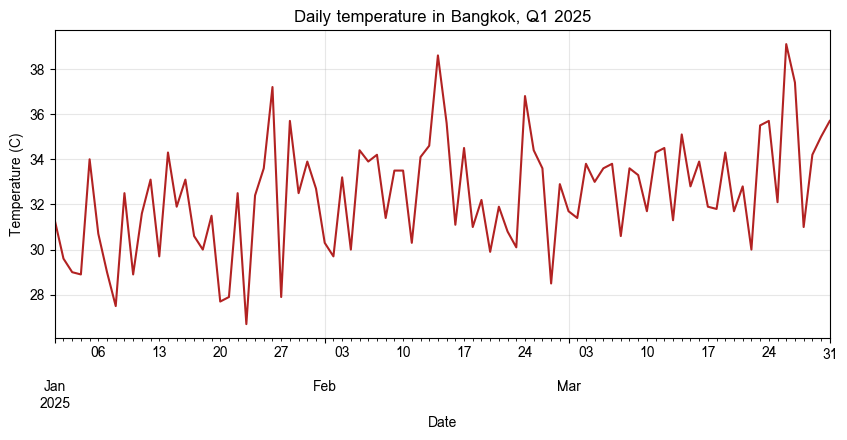

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

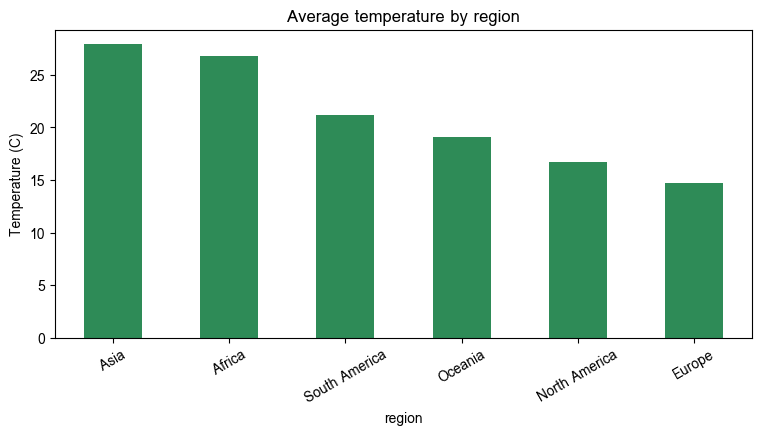

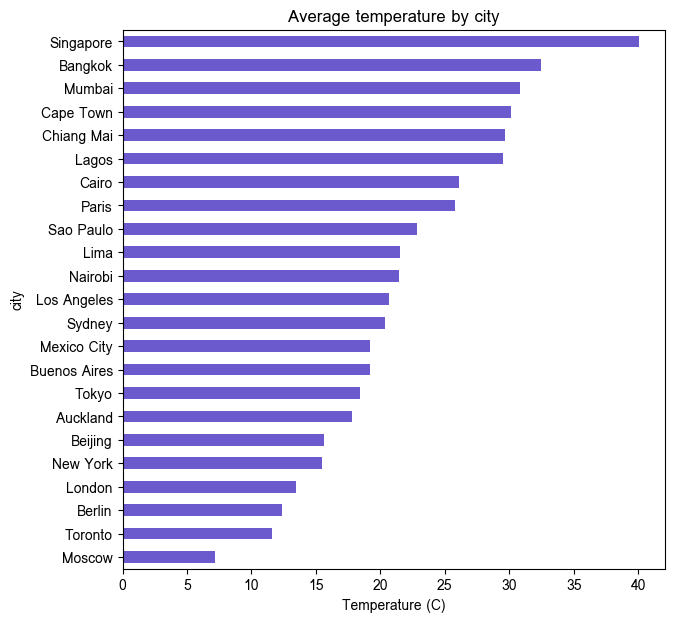

In [207]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

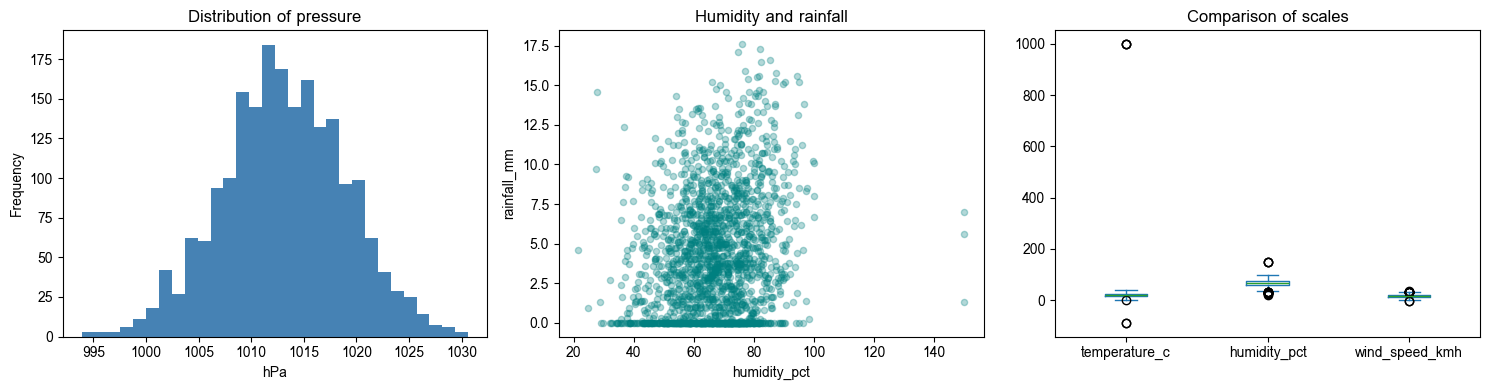

In [208]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

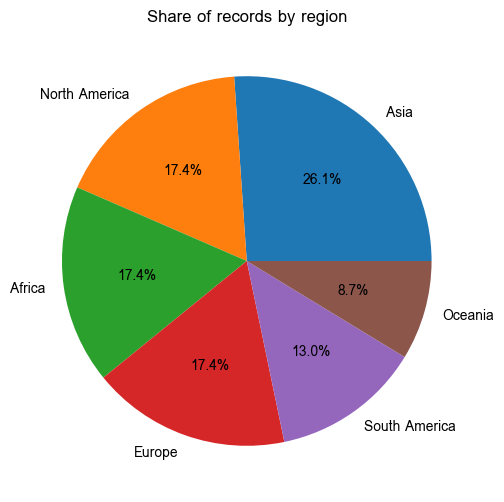

In [209]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

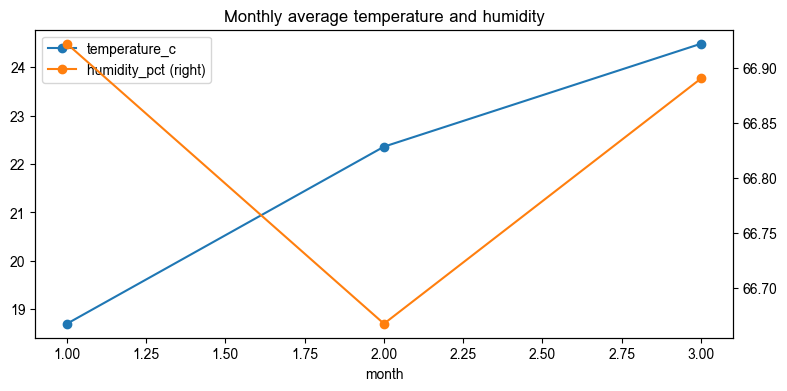

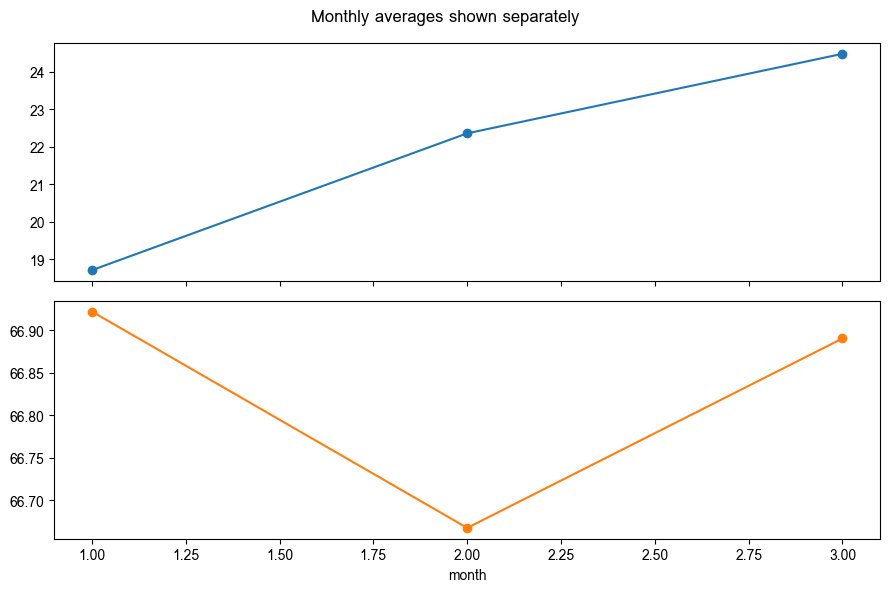

In [210]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

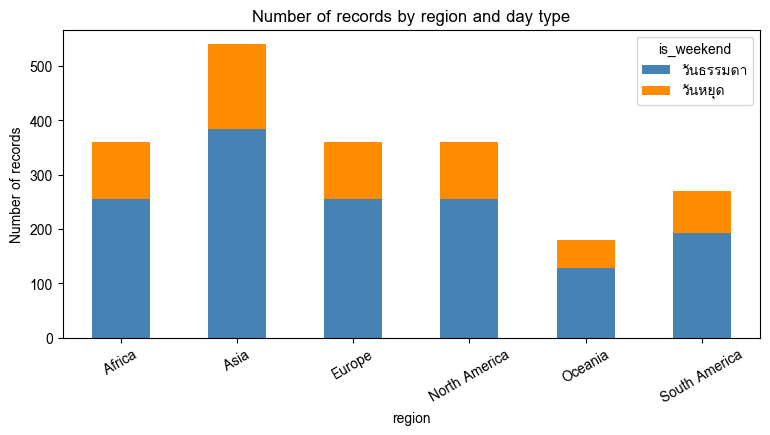

In [211]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

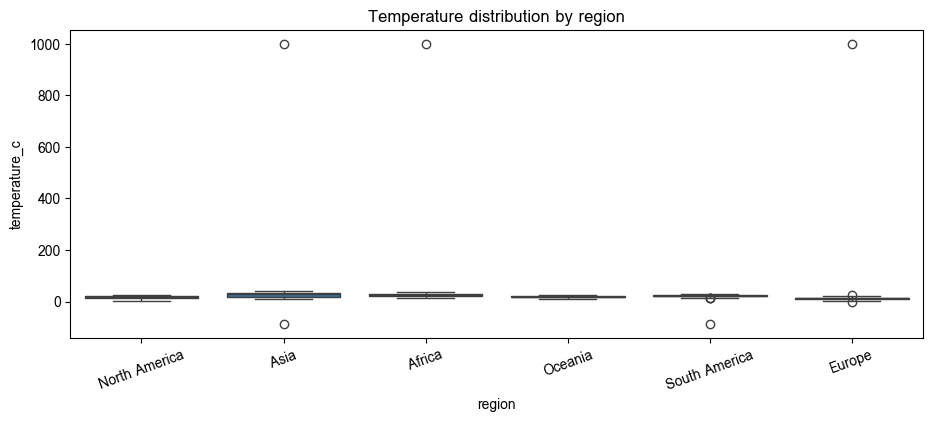

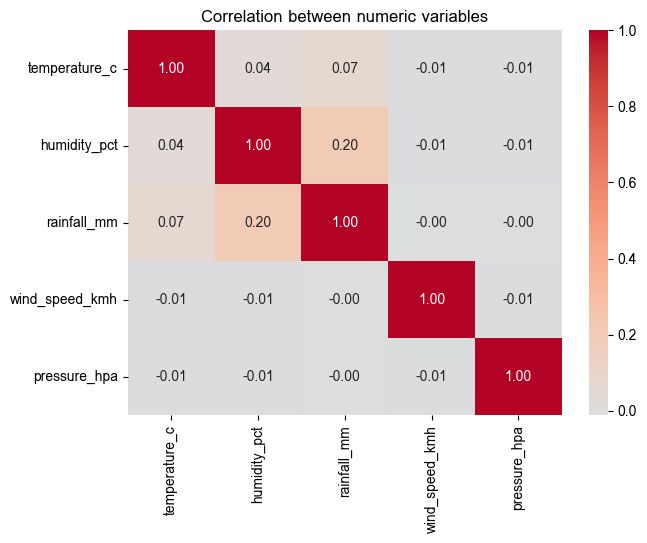

In [212]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

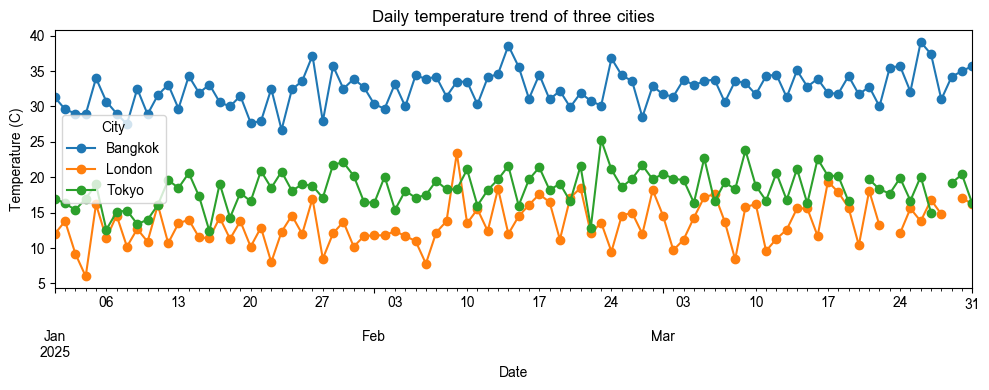

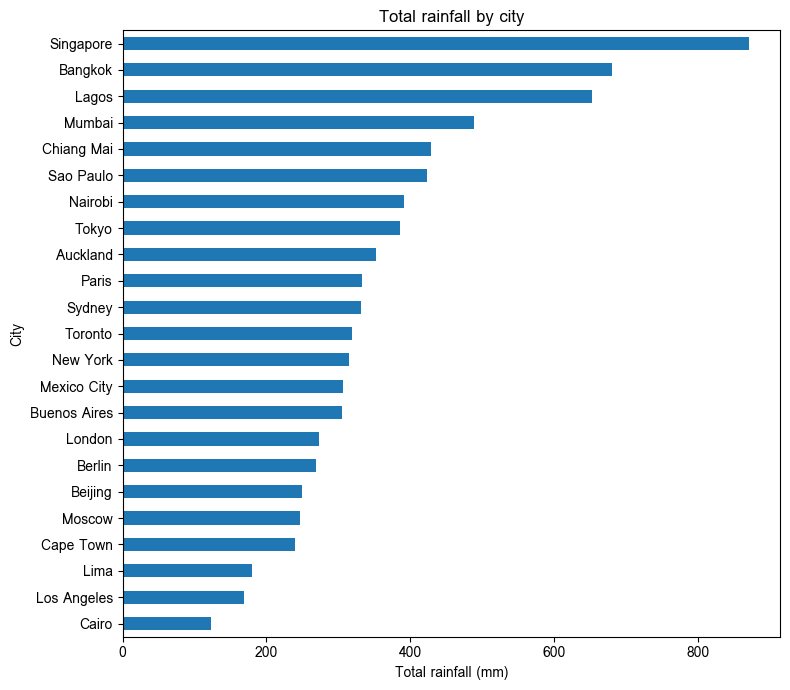

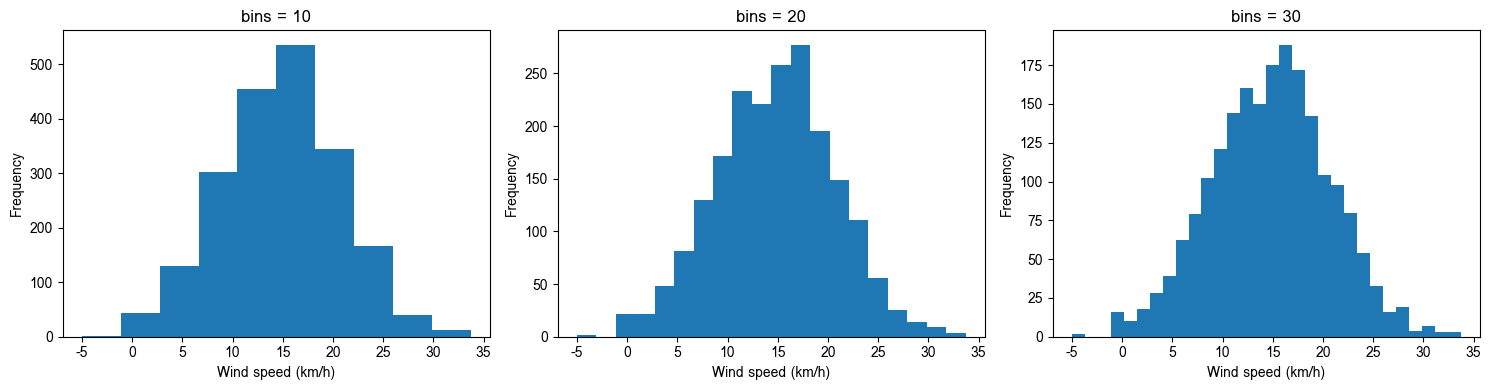

การเลือก bins น้อยทำให้เห็นภาพรวมของการกระจายได้ง่ายแต่รายละเอียดน้อย ส่วน bins มากทำให้เห็นรายละเอียดมากขึ้นแต่กราฟอาจดูผันผวน/รกกว่า


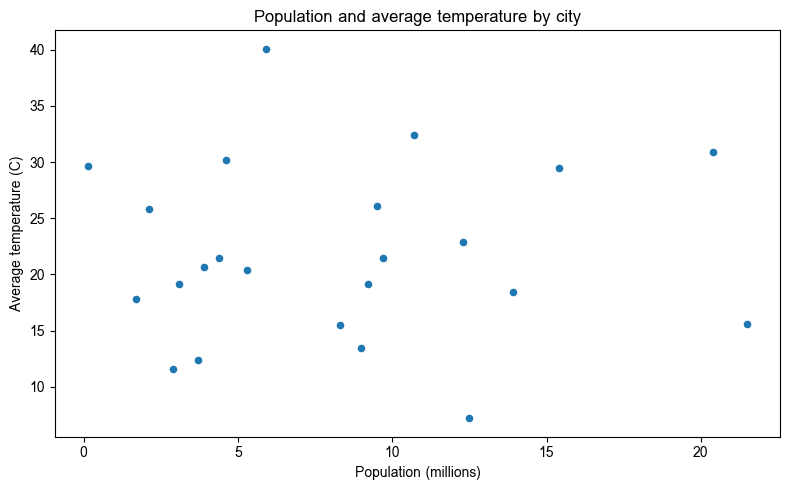

In [213]:
# คำตอบข้อ 17.1
selected_cities = ["Bangkok", "Tokyo", "London"]
city_plot = df[df["city"].isin(selected_cities)].copy()

# 1) แนวโน้มอุณหภูมิรายวันของ 3 เมือง
trend = (
    city_plot.pivot_table(
        index="date", columns="city",
        values="temperature_c", aggfunc="mean"
    )
    .sort_index()
)

ax = trend.plot(figsize=(10, 4), marker="o")
ax.set_title("Daily temperature trend of three cities")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.legend(title="City")
plt.tight_layout()
plt.show()

# 2) ปริมาณฝนรวมรายเมือง เรียงมาก -> น้อย
rain_by_city_plot = (
    df.groupby("city")["rainfall_mm"]
      .sum()
      .sort_values(ascending=True)
)

ax = rain_by_city_plot.plot(kind="barh", figsize=(8, 7))
ax.set_title("Total rainfall by city")
ax.set_xlabel("Total rainfall (mm)")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()

# 3) histogram ของ wind_speed_kmh ทดลอง 3 ค่า bins
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, bins in zip(axes, [10, 20, 30]):
    df["wind_speed_kmh"].plot(
        kind="hist", bins=bins, ax=ax, title=f"bins = {bins}"
    )
    ax.set_xlabel("Wind speed (km/h)")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print(
    "การเลือก bins น้อยทำให้เห็นภาพรวมของการกระจายได้ง่ายแต่รายละเอียดน้อย "
    "ส่วน bins มากทำให้เห็นรายละเอียดมากขึ้นแต่กราฟอาจดูผันผวน/รกกว่า"
)

# 4) จุด population กับอุณหภูมิเฉลี่ยรายเมือง
city_mean_temp = (
    df.groupby("city")["temperature_c"]
      .mean()
      .rename("avg_temp")
      .reset_index()
)

city_plot_data = city_info[["city", "population_millions"]].merge(
    city_mean_temp, on="city", how="inner"
)

ax = city_plot_data.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temp",
    figsize=(8, 5)
)
ax.set_title("Population and average temperature by city")
ax.set_xlabel("Population (millions)")
ax.set_ylabel("Average temperature (C)")
plt.tight_layout()
plt.show()


### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

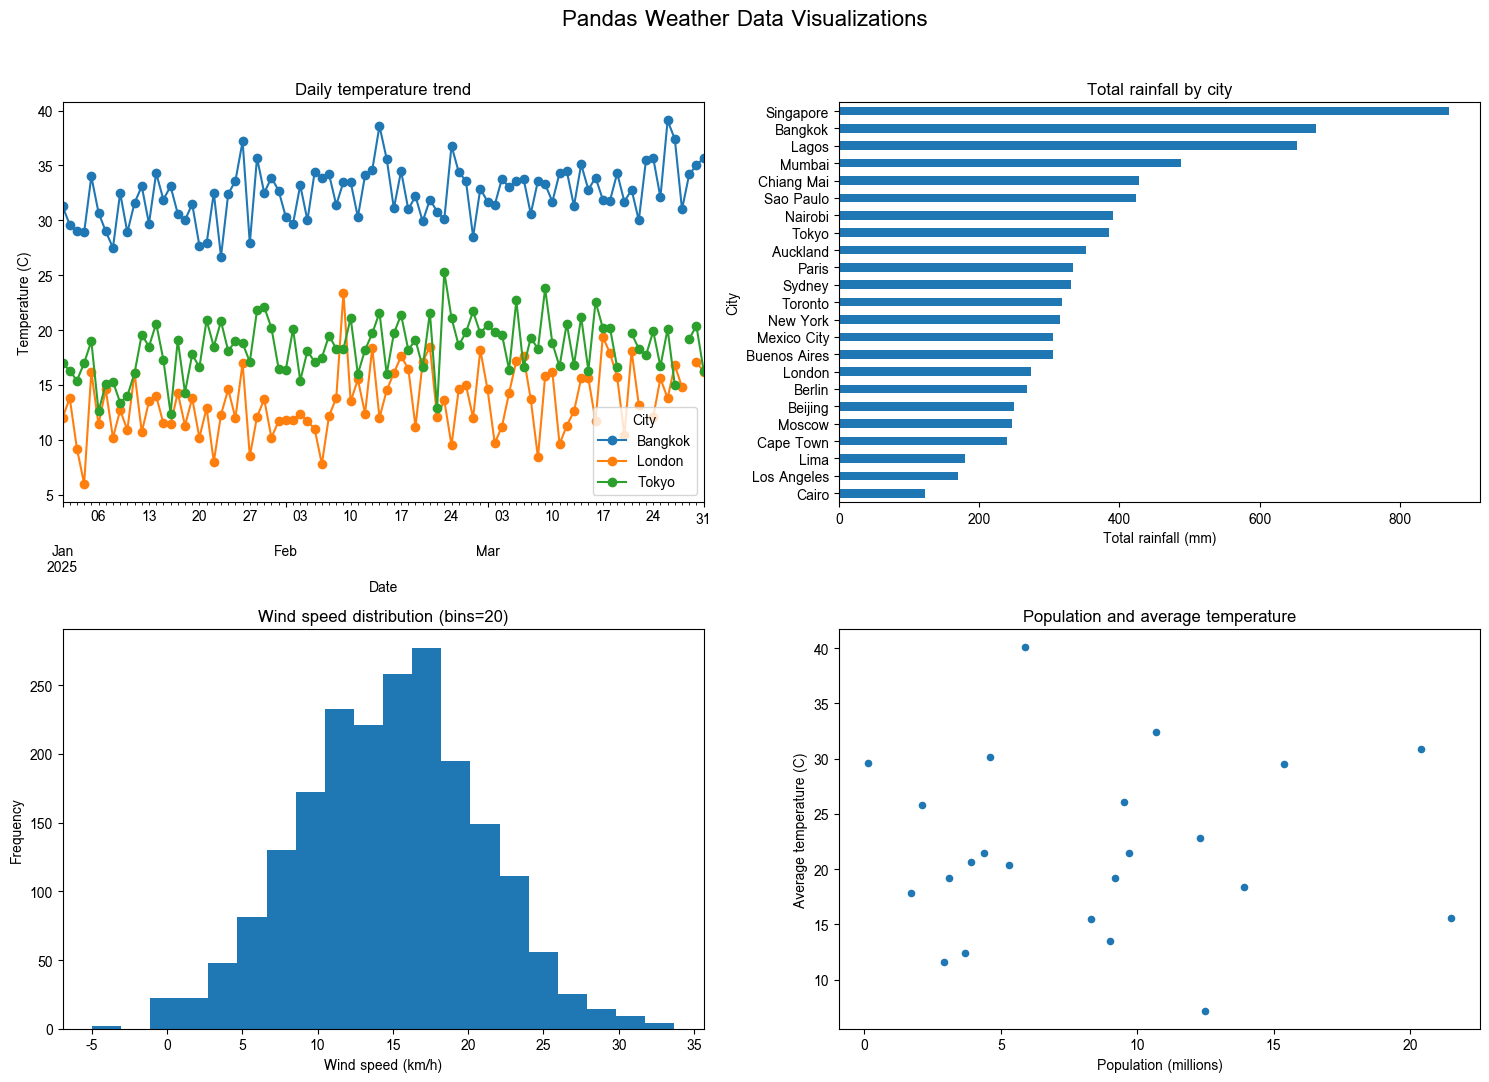

In [214]:
# คำตอบข้อ 17.2
selected_cities = ["Bangkok", "Tokyo", "London"]

trend = (
    df[df["city"].isin(selected_cities)]
      .pivot_table(
          index="date", columns="city",
          values="temperature_c", aggfunc="mean"
      )
      .sort_index()
)

rain_by_city_plot = (
    df.groupby("city")["rainfall_mm"]
      .sum()
      .sort_values(ascending=True)
)

city_mean_temp = (
    df.groupby("city")["temperature_c"]
      .mean()
      .rename("avg_temp")
      .reset_index()
)
city_plot_data = city_info[["city", "population_millions"]].merge(
    city_mean_temp, on="city", how="inner"
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

trend.plot(ax=axes[0, 0], marker="o")
axes[0, 0].set_title("Daily temperature trend")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (C)")
axes[0, 0].legend(title="City")

rain_by_city_plot.plot(kind="barh", ax=axes[0, 1])
axes[0, 1].set_title("Total rainfall by city")
axes[0, 1].set_xlabel("Total rainfall (mm)")
axes[0, 1].set_ylabel("City")

df["wind_speed_kmh"].plot(
    kind="hist", bins=20, ax=axes[1, 0]
)
axes[1, 0].set_title("Wind speed distribution (bins=20)")
axes[1, 0].set_xlabel("Wind speed (km/h)")
axes[1, 0].set_ylabel("Frequency")

city_plot_data.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temp",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Population and average temperature")
axes[1, 1].set_xlabel("Population (millions)")
axes[1, 1].set_ylabel("Average temperature (C)")

plt.suptitle("Pandas Weather Data Visualizations", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

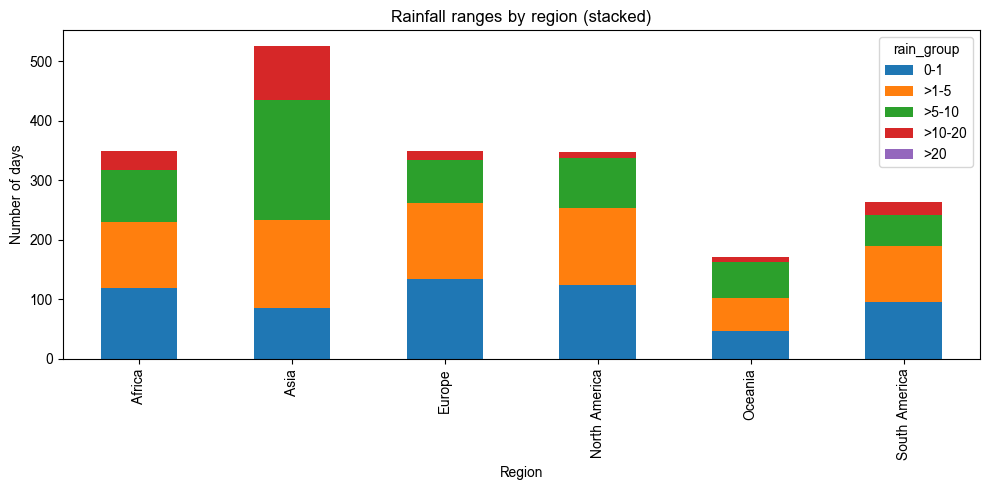

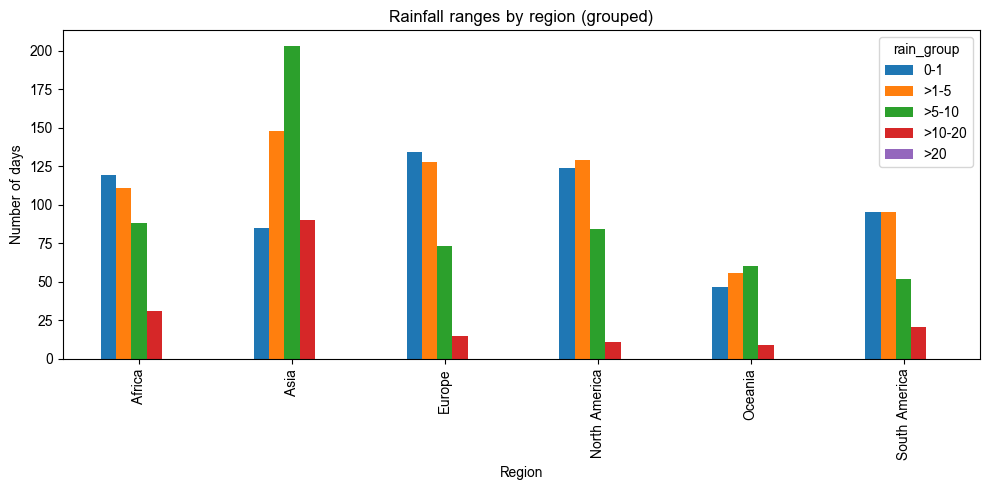

กราฟแท่งซ้อนเหมาะเมื่ออยากเห็นทั้งยอดรวมของแต่ละภูมิภาค และองค์ประกอบของช่วงฝนภายในยอดรวมนั้น
กราฟแท่งเรียงข้างกันเหมาะเมื่อเน้นเปรียบเทียบค่าของแต่ละช่วงฝน ระหว่างภูมิภาคโดยตรงและต้องการอ่านความแตกต่างของแต่ละกลุ่มง่ายกว่า


In [215]:
# คำตอบข้อ 17.3
rain_bins = [-np.inf, 1, 5, 10, 20, np.inf]
rain_labels = [
    "0-1", ">1-5", ">5-10", ">10-20", ">20"
]

df["rain_group"] = pd.cut(
    df["rainfall_mm"],
    bins=rain_bins,
    labels=rain_labels,
    include_lowest=True
)

rain_region = (
    df.groupby(["region", "rain_group"], observed=False)
      .size()
      .unstack(fill_value=0)
)

ax = rain_region.plot(
    kind="bar", stacked=True, figsize=(10, 5)
)
ax.set_title("Rainfall ranges by region (stacked)")
ax.set_xlabel("Region")
ax.set_ylabel("Number of days")
plt.tight_layout()
plt.show()

ax = rain_region.plot(
    kind="bar", stacked=False, figsize=(10, 5)
)
ax.set_title("Rainfall ranges by region (grouped)")
ax.set_xlabel("Region")
ax.set_ylabel("Number of days")
plt.tight_layout()
plt.show()

print(
    "กราฟแท่งซ้อนเหมาะเมื่ออยากเห็นทั้งยอดรวมของแต่ละภูมิภาค "
    "และองค์ประกอบของช่วงฝนภายในยอดรวมนั้น"
)
print(
    "กราฟแท่งเรียงข้างกันเหมาะเมื่อเน้นเปรียบเทียบค่าของแต่ละช่วงฝน "
    "ระหว่างภูมิภาคโดยตรงและต้องการอ่านความแตกต่างของแต่ละกลุ่มง่ายกว่า"
)


### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

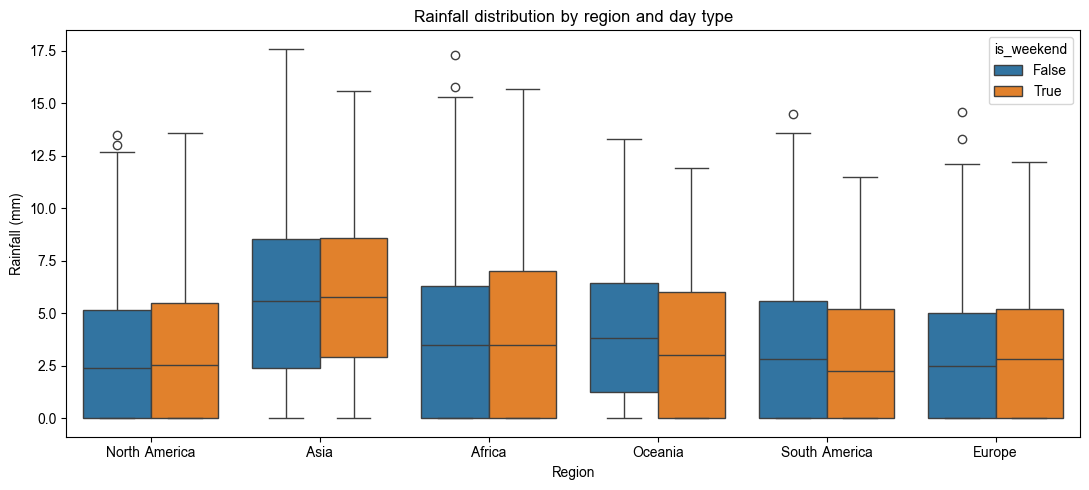

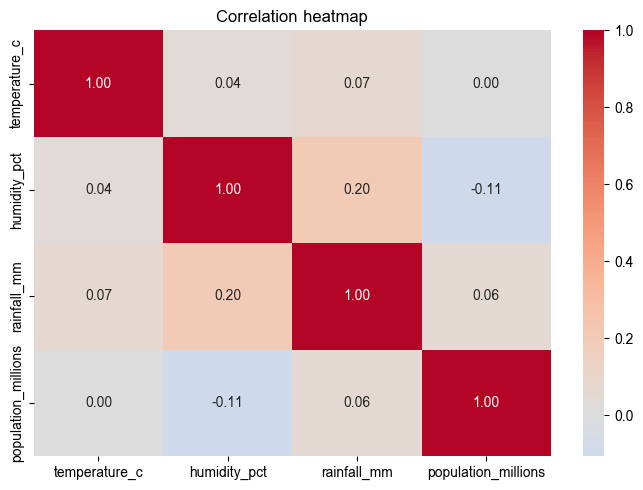

เมทริกซ์สหสัมพันธ์
                     temperature_c  humidity_pct  rainfall_mm  \
temperature_c                 1.00          0.04         0.07   
humidity_pct                  0.04          1.00         0.20   
rainfall_mm                   0.07          0.20         1.00   
population_millions           0.00         -0.11         0.06   

                     population_millions  
temperature_c                       0.00  
humidity_pct                       -0.11  
rainfall_mm                         0.06  
population_millions                 1.00  

สหสัมพันธ์ที่มีค่าสัมบูรณ์สูงสุดคือ rainfall_mm กับ humidity_pct = 0.20

ตีความ: ค่าใกล้ +1 หมายถึงสัมพันธ์เชิงบวกมาก ค่าใกล้ -1 หมายถึงสัมพันธ์เชิงลบมาก และค่าใกล้ 0 หมายถึงความสัมพันธ์เชิงเส้นต่ำ


In [216]:
# คำตอบข้อ 17.4
df["is_weekend"] = df["date"].dt.dayofweek >= 5

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df,
    x="region",
    y="rainfall_mm",
    hue="is_weekend",
    ax=ax
)
ax.set_title("Rainfall distribution by region and day type")
ax.set_xlabel("Region")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

numeric_cols = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "population_millions"
]
heatmap_data = df.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left",
    suffixes=("", "_cityinfo")
)

corr = heatmap_data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax
)
ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.show()

print("เมทริกซ์สหสัมพันธ์")
print(corr.round(2))

off_diag = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
    .stack()
    .sort_values(key=np.abs, ascending=False)
)
if not off_diag.empty:
    pair = off_diag.index[0]
    value = off_diag.iloc[0]
    print(
        f"\nสหสัมพันธ์ที่มีค่าสัมบูรณ์สูงสุดคือ {pair[0]} กับ {pair[1]} = {value:.2f}"
    )
print(
    "\nตีความ: ค่าใกล้ +1 หมายถึงสัมพันธ์เชิงบวกมาก "
    "ค่าใกล้ -1 หมายถึงสัมพันธ์เชิงลบมาก และค่าใกล้ 0 หมายถึงความสัมพันธ์เชิงเส้นต่ำ"
)


---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [217]:
# คำตอบข้อ 18.1
analysis_df = merged_all.copy()

analysis_df["temp_analysis"] = analysis_df["temperature_c"].where(
    analysis_df["temperature_c"].between(-60, 60)
)

city_var = (
    analysis_df.groupby(["region", "city"])["temp_analysis"]
    .std()
    .rename("city_temp_std")
    .reset_index()
)

region_var = (
    analysis_df.groupby("region")["temp_analysis"]
    .std()
    .rename("region_temp_std")
    .reset_index()
)

region_detail = (
    region_var.merge(
        city_var.groupby("region")["city_temp_std"]
        .agg(
            mean_city_std="mean",
            max_city_std="max",
            min_city_std="min"
        )
        .reset_index(),
        on="region",
        how="left"
    )
    .assign(
        max_vs_mean_city_std=lambda x:
            x["max_city_std"] / x["mean_city_std"]
    )
    .sort_values("region_temp_std", ascending=False)
)

dominant_city = (
    city_var.loc[
        city_var.groupby("region")["city_temp_std"].idxmax(),
        ["region", "city", "city_temp_std"]
    ]
    .rename(columns={"city": "highest_std_city"})
)

region_detail = region_detail.merge(
    dominant_city,
    on="region",
    how="left"
)

print(region_detail.round(2))

most_variable = region_detail.iloc[0]
print(
    f"\nภูมิภาคที่อุณหภูมิรายวันแปรปรวนมากที่สุดคือ "
    f"{most_variable['region']} "
    f"(SD = {most_variable['region_temp_std']:.2f})"
)

print(
    "การดู max_vs_mean_city_std และ highest_std_city ช่วยตรวจว่า "
    "ความแปรปรวนมาจากเมืองหนึ่งเป็นหลักหรือกระจายอยู่หลายเมือง"
)

print(
    "\nวิธีจัดการข้อมูล: ใช้เฉพาะ temperature_c ที่อยู่ในช่วง -60 ถึง 60 "
    "และปล่อยค่าว่างให้ข้ามการคำนวณ SD"
)


          region  region_temp_std  mean_city_std  max_city_std  min_city_std  \
0           Asia             7.16           2.67          2.87          2.49   
1         Africa             4.88           2.79          2.85          2.74   
2  North America             4.52           2.87          3.02          2.71   
3         Europe             4.07           2.88          3.03          2.60   
4        Oceania             3.08           2.81          2.82          2.80   
5  South America             3.06           2.89          3.11          2.78   

   max_vs_mean_city_std highest_std_city  city_temp_std  
0                  1.08          Beijing           2.87  
1                  1.02          Nairobi           2.85  
2                  1.05         New York           3.02  
3                  1.05            Paris           3.03  
4                  1.00           Sydney           2.82  
5                  1.08             Lima           3.11  

ภูมิภาคที่อุณหภูมิรายวันแปรปรวนม

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [218]:
# คำตอบข้อ 18.2
rain_compare = (
    analysis_df.groupby("city")
    .agg(
        heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
        observed_rain_days=("rainfall_mm", "count"),
    )
    .assign(
        heavy_rain_pct=lambda x:
            x["heavy_rain_days"] / x["observed_rain_days"] * 100
    )
)

rain_compare["rank_by_count"] = (
    rain_compare["heavy_rain_days"]
    .rank(method="min", ascending=False)
)
rain_compare["rank_by_pct"] = (
    rain_compare["heavy_rain_pct"]
    .rank(method="min", ascending=False)
)

comparison_182 = (
    rain_compare.loc[
        (rain_compare["rank_by_count"] <= 5)
        | (rain_compare["rank_by_pct"] <= 5)
    ]
    .sort_values(
        ["rank_by_pct", "rank_by_count"],
        na_position="last"
    )
)

print(comparison_182.round(2))

count_top5 = (
    rain_compare.nlargest(5, "heavy_rain_days")
    .index.tolist()
)
pct_top5 = (
    rain_compare.nlargest(5, "heavy_rain_pct")
    .index.tolist()
)

print("\nTop 5 ตามจำนวนวัน:", count_top5)
print("Top 5 ตามสัดส่วน:", pct_top5)

print(
    "\nอธิบาย: จำนวนวันให้ความสำคัญกับเมืองที่มีจำนวน observation มากกว่า "
    "แต่สัดส่วนปรับตามจำนวนวันที่มีข้อมูล จึงสามารถจัดอันดับต่างกันได้"
)


              heavy_rain_days  observed_rain_days  heavy_rain_pct  \
city                                                                
Singapore                  44                  90           48.89   
Bangkok                    23                  87           26.44   
Lagos                      22                  88           25.00   
Sao Paulo                  11                  88           12.50   
Chiang Mai                  9                  85           10.59   
Buenos Aires                9                  88           10.23   

              rank_by_count  rank_by_pct  
city                                      
Singapore               1.0          1.0  
Bangkok                 2.0          2.0  
Lagos                   3.0          3.0  
Sao Paulo               4.0          4.0  
Chiang Mai              5.0          5.0  
Buenos Aires            5.0          6.0  

Top 5 ตามจำนวนวัน: ['Singapore', 'Bangkok', 'Lagos', 'Sao Paulo', 'Buenos Aires']
Top 5 ตามสัดส่วน: ['

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [219]:
# คำตอบข้อ 18.3
city_analysis = (
    analysis_df.groupby("city")
    .agg(
        population_millions=("population_millions", "first"),
        avg_temp=("temp_analysis", "mean"),
        total_rain=("rainfall_mm", "sum"),
    )
)

corr_population = (
    city_analysis[
        ["population_millions", "avg_temp", "total_rain"]
    ]
    .corr()["population_millions"]
    .drop("population_millions")
    .rename("correlation")
    .to_frame()
)

print("สหสัมพันธ์ของประชากรกับอุณหภูมิเฉลี่ยและปริมาณฝนรวมรายเมือง")
print(corr_population.round(3))

print(
    "\nข้อควรระวัง: correlation บอกเพียงความสัมพันธ์เชิงเส้น ไม่ได้แปลว่า "
    "ประชากรเป็นสาเหตุของอุณหภูมิหรือฝน และการวิเคราะห์นี้มีจำนวนเมืองจำกัด "
    "รวมทั้งตัวแปรภูมิภาค/ภูมิอากาศและฤดูกาลอาจเป็นตัวแปรแทรกซ้อน"
)


สหสัมพันธ์ของประชากรกับอุณหภูมิเฉลี่ยและปริมาณฝนรวมรายเมือง
            correlation
avg_temp          0.159
total_rain        0.128

ข้อควรระวัง: correlation บอกเพียงความสัมพันธ์เชิงเส้น ไม่ได้แปลว่า ประชากรเป็นสาเหตุของอุณหภูมิหรือฝน และการวิเคราะห์นี้มีจำนวนเมืองจำกัด รวมทั้งตัวแปรภูมิภาค/ภูมิอากาศและฤดูกาลอาจเป็นตัวแปรแทรกซ้อน


4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [220]:
# คำตอบข้อ 18.4
travel_month = (
    analysis_df.groupby(["region", "month"])
    .agg(
        heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
        observed_rain_days=("rainfall_mm", "count"),
        avg_rain=("rainfall_mm", "mean"),
    )
    .assign(
        heavy_rain_pct=lambda x:
            x["heavy_rain_days"] / x["observed_rain_days"] * 100
    )
    .reset_index()
)

# เกณฑ์: เลือกเดือนที่มี "สัดส่วนวันฝนหนัก" สูงสุดของแต่ละภูมิภาค
# และใช้ avg_rain เป็นตัวตัดสินเมื่อสัดส่วนเท่ากัน
avoid = (
    travel_month.sort_values(
        ["region", "heavy_rain_pct", "avg_rain"],
        ascending=[True, False, False]
    )
    .groupby("region", as_index=False)
    .head(1)
    .sort_values("region")
)

print(avoid.round(2))

print(
    "\nเกณฑ์ที่เลือกใช้: ให้สัดส่วนวันฝนหนัก (>10 mm) เป็นตัวชี้วัดหลัก "
    "เพราะสะท้อน 'ความถี่ของวันที่เสี่ยงต่อการเดินทาง' และปรับตามจำนวนวันที่มีข้อมูลแล้ว "
    "ส่วนค่าเฉลี่ยฝนใช้เป็นตัวตัดสินกรณีที่สัดส่วนเท่ากัน"
)
print(
    "ดังนั้นเดือนที่อยู่ในตารางคือเดือนที่ควรหลีกเลี่ยงมากที่สุดตามเกณฑ์ที่กำหนด "
    "ไม่ใช่ข้อสรุปเชิงสาเหตุหรือการพยากรณ์สภาพอากาศในอนาคต"
)


           region  month  heavy_rain_days  observed_rain_days  avg_rain  \
0          Africa      1               12                 120      4.22   
4            Asia      2               38                 163      6.40   
8          Europe      3                7                 121      3.08   
10  North America      2                4                 109      3.26   
14        Oceania      3                6                  55      4.38   
15  South America      1                8                  91      3.34   

    heavy_rain_pct  
0            10.00  
4            23.31  
8             5.79  
10            3.67  
14           10.91  
15            8.79  

เกณฑ์ที่เลือกใช้: ให้สัดส่วนวันฝนหนัก (>10 mm) เป็นตัวชี้วัดหลัก เพราะสะท้อน 'ความถี่ของวันที่เสี่ยงต่อการเดินทาง' และปรับตามจำนวนวันที่มีข้อมูลแล้ว ส่วนค่าเฉลี่ยฝนใช้เป็นตัวตัดสินกรณีที่สัดส่วนเท่ากัน
ดังนั้นเดือนที่อยู่ในตารางคือเดือนที่ควรหลีกเลี่ยงมากที่สุดตามเกณฑ์ที่กำหนด ไม่ใช่ข้อสรุปเชิงสาเหตุหรือการพยากรณ์สภาพอากาศใน

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️